In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the CSV
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [3]:
# read in station names CSV
path = 'E:/Central Valley Fog/station_names.csv'
if os.path.exists(path):
    station_names = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/station_names.csv'
    station_names = pd.read_csv(path, low_memory = False)

print(station_names)

     STATION_ID                                     STATION  BEGIN_DATE  \
0   USW00023155                              BAKERSFIELD AP  1927-12-31   
1   USW00093216                                   BEALE AFB  1959-06-30   
2   USI0000KC83                                       BYRON  2017-08-30   
3   USW00023203                                  CASTLE AFB  1941-12-31   
4   USW00093203                    CHICO ARMY FLYING SCHOOL  1942-05-05   
5   USI0000KDLO                                 DELANO MUNI  2017-01-05   
6   USW00053125                                      FRESNO  1892-12-31   
7   USW00023167                 FRESNO CHANDLER DOWNTOWN AP  1933-04-30   
8   USW00093193                        FRESNO YOSEMITE INTL  1941-12-03   
9   USM00074917                                 GARDNER AAF  1941-11-30   
10  USW00023106                                  HAMMER AAF  1942-01-01   
11  USW00053119                        HANFORD MUNICIPAL AP  1998-02-18   
12  USW00023110          

In [4]:
station_id_to_name = station_names.set_index('STATION_ID')['STATION']

CV_rows = CV_rows.rename(columns={'STATION': 'STATION_ID'})
CV_rows['STATION'] = CV_rows['STATION_ID'].map(station_id_to_name).fillna(CV_rows['STATION_ID'])

print(CV_rows[['STATION_ID', 'STATION']].head())

    STATION_ID      STATION
0  USM00074917  GARDNER AAF
1  USM00074917  GARDNER AAF
2  USM00074917  GARDNER AAF
3  USM00074917  GARDNER AAF
4  USM00074917  GARDNER AAF


In [5]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [6]:
#Looking at fresno station rows for the one dating back the farthest (40 or 80 km visibility??)
station_rows = CV_rows[CV_rows['STATION_ID'] == 'USW00053125']
print("USW00053125 rows:", station_rows.shape)
print(station_rows)

USW00053125 rows: (1939, 12)
         STATION_ID  LATITUDE  LONGITUDE                 DATE  \
581317  USW00053125  36.73333     -119.8  1933-01-01 02:00:00   
581318  USW00053125  36.73333     -119.8  1933-01-01 05:00:00   
581319  USW00053125  36.73333     -119.8  1933-01-01 09:00:00   
581320  USW00053125  36.73333     -119.8  1933-01-01 12:00:00   
581321  USW00053125  36.73333     -119.8  1933-01-01 17:00:00   
...             ...       ...        ...                  ...   
583257  USW00053125  36.73333     -119.8  1939-04-29 16:00:00   
583258  USW00053125  36.73333     -119.8  1939-04-30 00:00:00   
583259  USW00053125  36.73333     -119.8  1939-04-30 04:00:00   
583260  USW00053125  36.73333     -119.8  1939-04-30 13:00:00   
583261  USW00053125  36.73333     -119.8  1939-04-30 16:00:00   

        HourlyPrecipitation  HourlyVisibility  year  month  day  hour  minute  \
581317                  0.0             6.437  1933      1    1     2       0   
581318                  0.0 

In [7]:
#filetering for rows where there is fog based on precipitation and visibility thresholds
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (212676, 12)


In [6]:
# station_fog_rows = CV_fog_rows[CV_fog_rows['STATION'] == 'USW00053125']
# station_fog_rows = CV_fog_rows[CV_fog_rows['STATION'] == 'USW00023167']
# print("USW00023167 fog rows:", station_fog_rows.shape)
# station_fog_rows

In [8]:
#counting fog days per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())


          STATION  year  fog_days
0  BAKERSFIELD AP  1928        12
1  BAKERSFIELD AP  1929        21
2  BAKERSFIELD AP  1930        12
3  BAKERSFIELD AP  1931        19
4  BAKERSFIELD AP  1932        10


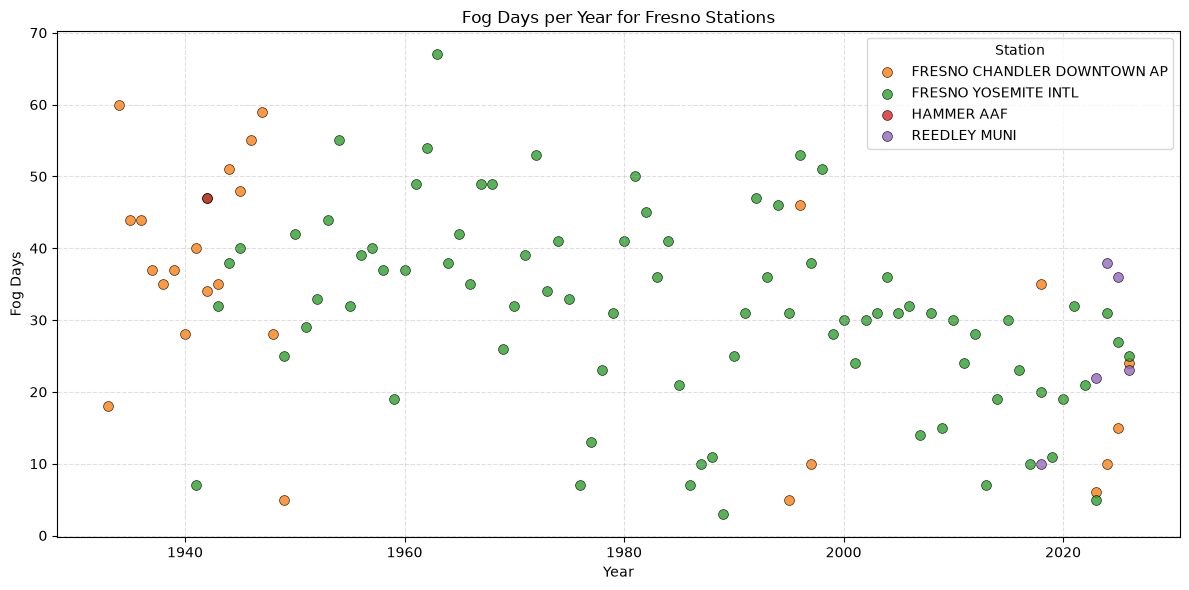

In [9]:
#checking fog days for fresno stations
stations = ['FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'HAMMER AAF', 'REEDLEY MUNI']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

plt.figure(figsize=(12, 6))

for station, color in zip(stations, colors):
    station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')
    if station_df.empty:
        continue

    plt.scatter(
        station_df['year'],
        station_df['fog_days'],
        s=50,
        color=color,
        alpha=0.8,
        label=station,
        edgecolor='black',
        linewidth=0.5
    )

plt.title('Fog Days per Year for Fresno Stations')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', loc='best')
plt.tight_layout()
plt.show()

In [10]:
#counting dense fog days per year per station
CV_densefog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 0.403)
]

print("CV_densefog_rows:", CV_densefog_rows.shape)

CV_densefog_rows: (144572, 12)


In [11]:
densefog_days_year = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(densefog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928         3
1  BAKERSFIELD AP  1929        11
2  BAKERSFIELD AP  1930         7
3  BAKERSFIELD AP  1931        17
4  BAKERSFIELD AP  1932         8


In [12]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'USW00023242', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


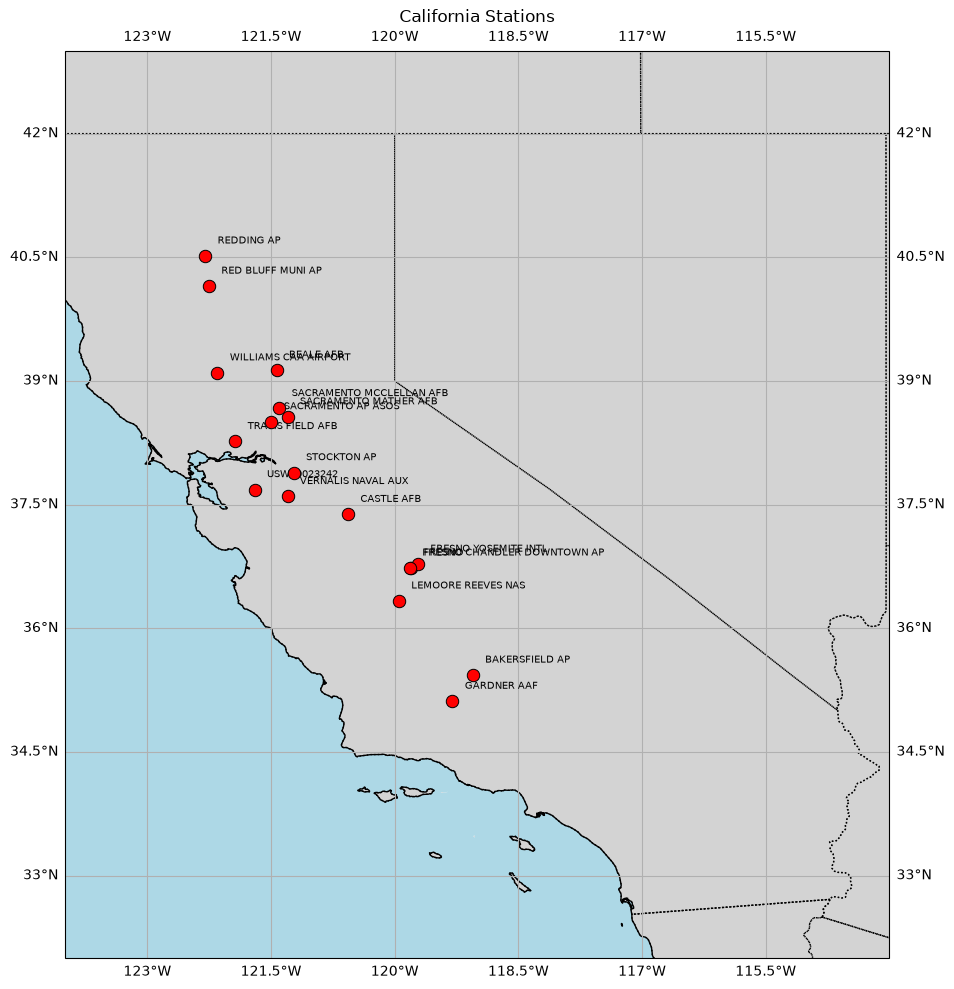

In [13]:
# Plot the stations locations on a map of California
station_locs_ca = station_locations.dropna(subset=['LATITUDE', 'LONGITUDE'])

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-124, -114, 32, 43], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES, linestyle=':')
ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.scatter(
    station_locs_ca['LONGITUDE'],
    station_locs_ca['LATITUDE'],
    s=80,
    color='red',
    edgecolor='black',
    linewidth=0.7,
    transform=ccrs.PlateCarree(),
    zorder=5
)

for _, row in station_locs_ca.iterrows():
    ax.text(
        row['LONGITUDE'] + 0.15,
        row['LATITUDE'] + 0.15,
        row['STATION'],
        transform=ccrs.PlateCarree(),
        fontsize=7
    )

ax.gridlines(draw_labels=True)
plt.title('California Stations')
plt.tight_layout()
plt.show()

Compare calculated heavy fog to what was recorded as monthly number days with heavy fog

In [14]:
# read in the CSV
path1 = 'E:/Central Valley Fog/fog_rows_cleaned.csv'
if os.path.exists(path1):
    CVfog_rows = pd.read_csv(path1, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/fog_rows_cleaned.csv'
    CVfog_rows = pd.read_csv(path, low_memory = False)



print(CVfog_rows)

          STATION  LATITUDE  LONGITUDE                 DATE  \
0     USW00053119  36.31889 -119.62889  2006-01-31T23:59:00   
1     USW00053119  36.31889 -119.62889  2006-02-28T23:59:00   
2     USW00053119  36.31889 -119.62889  2006-03-31T23:59:00   
3     USW00053119  36.31889 -119.62889  2006-04-30T23:59:00   
4     USW00053119  36.31889 -119.62889  2006-10-31T23:59:00   
...           ...       ...        ...                  ...   
2480  USW00024257  40.51750 -122.29860  2024-11-30T23:59:00   
2481  USW00024257  40.51750 -122.29860  2025-02-28T23:59:00   
2482  USW00024257  40.51750 -122.29860  2025-03-31T23:59:00   
2483  USW00024257  40.51750 -122.29860  2026-01-31T23:59:00   
2484  USW00024257  40.51750 -122.29860  2026-02-28T23:59:00   

      HourlyPrecipitation  HourlyVisibility  MonthlyNumberDaysWithHeavyFog  
0                     NaN               NaN                           19.0  
1                     NaN               NaN                           16.0  
2           

In [15]:

CVfog_rows = CVfog_rows.rename(columns={'STATION': 'STATION_ID'})
CVfog_rows['STATION'] = CVfog_rows['STATION_ID'].map(station_id_to_name).fillna(CVfog_rows['STATION_ID'])

print(CVfog_rows[['STATION_ID', 'STATION']].head())

    STATION_ID               STATION
0  USW00053119  HANFORD MUNICIPAL AP
1  USW00053119  HANFORD MUNICIPAL AP
2  USW00053119  HANFORD MUNICIPAL AP
3  USW00053119  HANFORD MUNICIPAL AP
4  USW00053119  HANFORD MUNICIPAL AP


In [16]:
densefog_days_per_month_station = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year', 'month'], as_index=False)
    .size()
    .rename(columns={'size': 'heavy_fog_days'})
    .sort_values(['STATION', 'year', 'month'])
)

print(densefog_days_per_month_station.head())
print(densefog_days_per_month_station.tail())
print("shape:", densefog_days_per_month_station.shape)

          STATION  year  month  heavy_fog_days
0  BAKERSFIELD AP  1928     12               3
1  BAKERSFIELD AP  1929      1               2
2  BAKERSFIELD AP  1929      2               1
3  BAKERSFIELD AP  1929     12               8
4  BAKERSFIELD AP  1930      1               2
                   STATION  year  month  heavy_fog_days
5478  WILLIAMS CAA AIRPORT  1952      3               2
5479  WILLIAMS CAA AIRPORT  1952      4               3
5480  WILLIAMS CAA AIRPORT  1952      5               1
5481  WILLIAMS CAA AIRPORT  1952     10               1
5482  WILLIAMS CAA AIRPORT  1952     12               9
shape: (5483, 4)


In [17]:
CVfog_rows['DATE'] = pd.to_datetime(CVfog_rows['DATE'])
CVfog_rows['year'] = CVfog_rows['DATE'].dt.year
CVfog_rows['month'] = CVfog_rows['DATE'].dt.month

monthly_heavy_fog_days = (
    CVfog_rows
    .groupby(['STATION', 'year', 'month'], as_index=False)
    ['MonthlyNumberDaysWithHeavyFog']
    .sum()
    .rename(columns={'MonthlyNumberDaysWithHeavyFog': 'heavy_fog_days'})
)

print(monthly_heavy_fog_days.head())

          STATION  year  month  heavy_fog_days
0  BAKERSFIELD AP  1965      1            13.0
1  BAKERSFIELD AP  1965      2             1.0
2  BAKERSFIELD AP  1965      4             1.0
3  BAKERSFIELD AP  1965     11             5.0
4  BAKERSFIELD AP  1965     12            17.0


In [18]:
comparison_heavy_fog = (
    densefog_days_per_month_station
    .merge(
        monthly_heavy_fog_days,
        on=['STATION', 'year', 'month'],
        how='outer',
        suffixes=('_calc', '_reported')
    )
)

comparison_heavy_fog['difference'] = (
    comparison_heavy_fog['heavy_fog_days_calc'].fillna(0)
    - comparison_heavy_fog['heavy_fog_days_reported'].fillna(0)
)
comparison_heavy_fog['calc_only'] = comparison_heavy_fog['heavy_fog_days_reported'].isna()
comparison_heavy_fog['reported_only'] = comparison_heavy_fog['heavy_fog_days_calc'].isna()

print("Total merged rows:", len(comparison_heavy_fog))
print("Rows with nonzero difference:", (comparison_heavy_fog['difference'] != 0).sum())
print("Rows only in calculated CV_densefog_rows aggregate:", comparison_heavy_fog['calc_only'].sum())
print("Rows only in reported CVfog_rows MonthlyNumberDaysWithHeavyFog:", comparison_heavy_fog['reported_only'].sum())

comparison_heavy_fog.sort_values('difference', key=lambda s: s.abs(), ascending=False).head(5)

Total merged rows: 5739
Rows with nonzero difference: 4390
Rows only in calculated CV_densefog_rows aggregate: 3254
Rows only in reported CVfog_rows MonthlyNumberDaysWithHeavyFog: 256


,STATION,year,month,heavy_fog_days_calc,heavy_fog_days_reported,difference,calc_only,reported_only
863,CASTLE AFB,1989,12,25.0,NaN,25.0,True,False
414,BEALE AFB,1963,12,24.0,NaN,24.0,True,False
1750,LEMOORE REEVES NAS,1973,12,NaN,23.0,-23.0,False,True
1350,FRESNO YOSEMITE INTL,1985,12,NaN,23.0,-23.0,False,True
4189,SACRAMENTO MCCLELLAN AFB,1961,1,23.0,NaN,23.0,True,False


In [19]:
comparison_heavy_fog = comparison_heavy_fog.loc[
    comparison_heavy_fog['heavy_fog_days_reported'].notna()
].copy()

print("Rows remaining:", comparison_heavy_fog.shape)

Rows remaining: (2485, 8)


In [20]:
comparison_heavy_fog['date'] = pd.to_datetime(
    dict(year=comparison_heavy_fog['year'],
         month=comparison_heavy_fog['month'],
         day=1)
)

comparison_heavy_fog = comparison_heavy_fog.sort_values('date')


In [19]:
# Plot difference in calculated vs reported heavy fog days
# stations = comparison_heavy_fog['STATION'].unique()
# colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

# plt.figure(figsize=(14, 6))
# for i, st in enumerate(stations):
#     sdf = comparison_heavy_fog[comparison_heavy_fog['STATION'] == st].sort_values('date')
#     if sdf.empty:
#         continue
#     plt.scatter(sdf['date'], sdf['difference'], s=30, color=colors[i], alpha=0.8, label=st)
#     plt.plot(sdf['date'], sdf['difference'], color=colors[i], linewidth=0.8, alpha=0.6)

# plt.axhline(0, color='gray', linewidth=1)
# plt.title('Difference in Heavy Fog Days: Calculated - Reported')
# plt.xlabel('Date')
# plt.ylabel('Difference (calc - reported)')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# plt.tight_layout()
# plt.show()

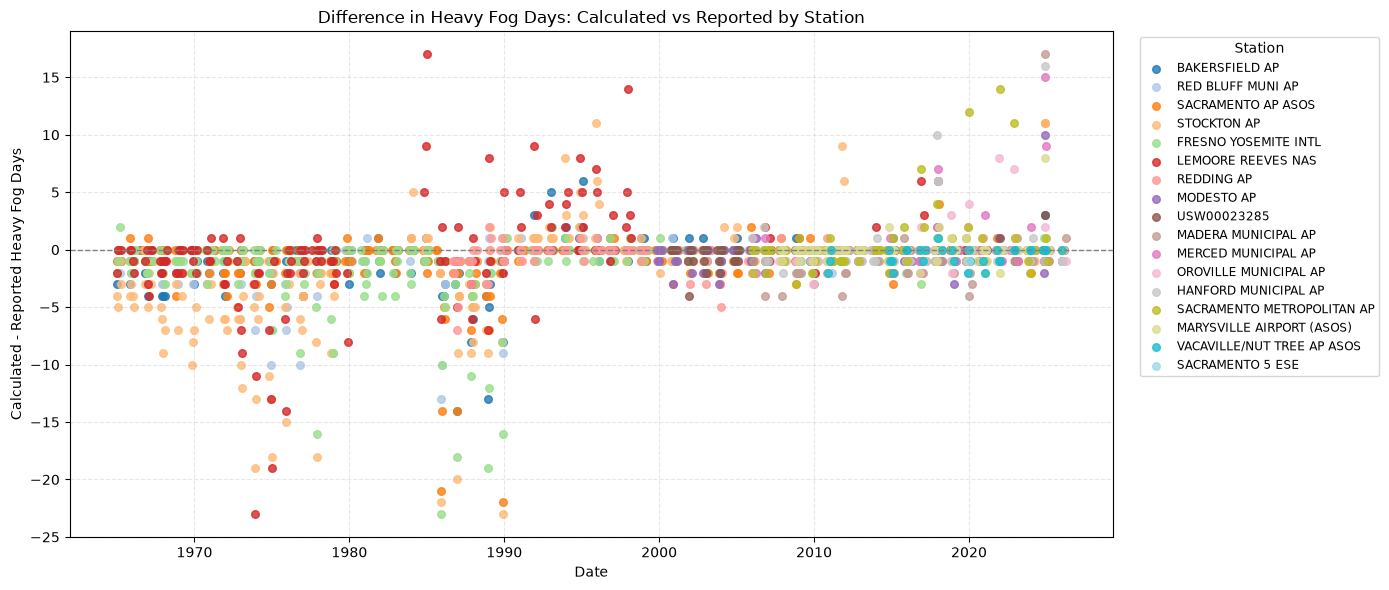

In [21]:
plt.figure(figsize=(14, 6))

stations = comparison_heavy_fog['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_data = comparison_heavy_fog[comparison_heavy_fog['STATION'] == station]
    plt.scatter(
        station_data['date'],
        station_data['difference'],
        s=30,
        color=colors[i],
        alpha=0.8,
        label=station,
        # edgecolors='black',
        # linewidth=0.5
    )

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.title('Difference in Heavy Fog Days: Calculated vs Reported by Station')
plt.xlabel('Date')
plt.ylabel('Calculated - Reported Heavy Fog Days')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

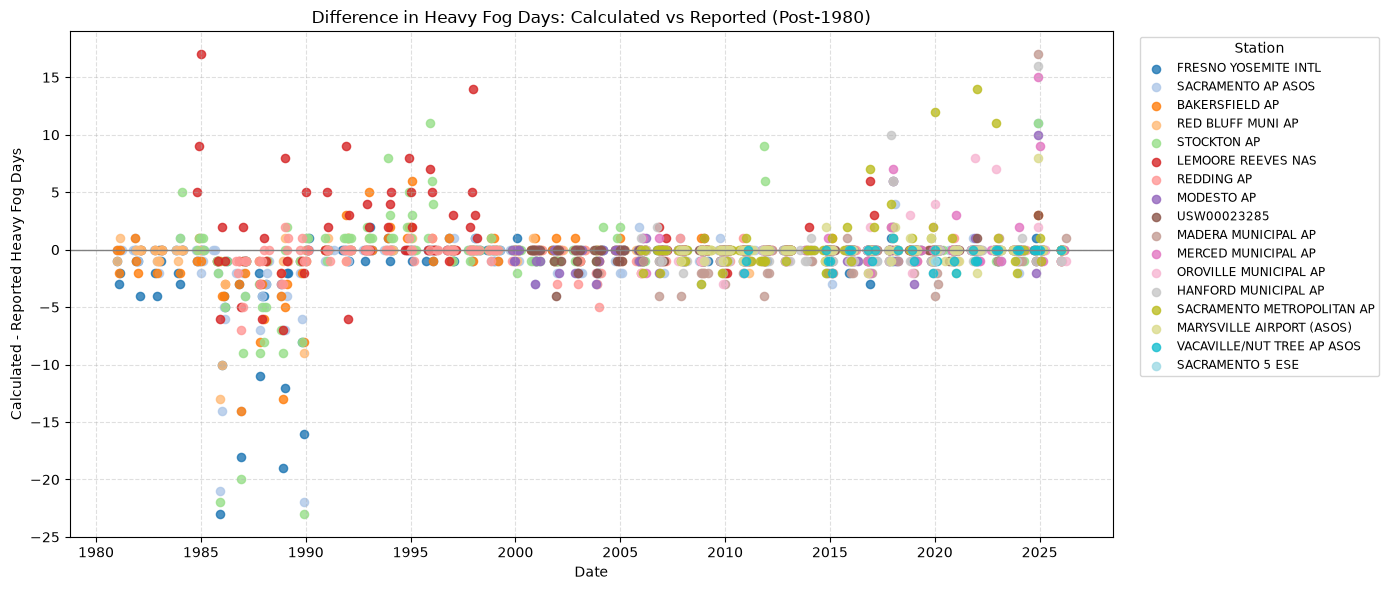

In [22]:
comparison_heavy_fog_post1980 = (
    comparison_heavy_fog.loc[
        comparison_heavy_fog["heavy_fog_days_reported"].notna()
        & (comparison_heavy_fog["year"] > 1980)
    ].copy()
)

if comparison_heavy_fog_post1980.empty:
    print("No post-1980 data available.")
else:
    comparison_heavy_fog_post1980["date"] = pd.to_datetime(comparison_heavy_fog_post1980["date"])

    stations = comparison_heavy_fog_post1980["STATION"].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

    plt.figure(figsize=(14, 6))
    for i, station in enumerate(stations):
        station_df = comparison_heavy_fog_post1980[
            comparison_heavy_fog_post1980["STATION"] == station
        ].sort_values("date")

        plt.scatter(
            station_df["date"],
            station_df["difference"],
            s=35,
            color=colors[i],
            alpha=0.8,
            label=station
        )

    plt.axhline(0, color="gray", linewidth=1)
    plt.title("Difference in Heavy Fog Days: Calculated vs Reported (Post-1980)")
    plt.xlabel("Date")
    plt.ylabel("Calculated - Reported Heavy Fog Days")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

In [23]:
# Monthly heavy fog days per station
CVfog_rows['DATE'] = pd.to_datetime(CVfog_rows['DATE'])
CVfog_rows['year'] = CVfog_rows['DATE'].dt.year
CVfog_rows['month'] = CVfog_rows['DATE'].dt.month

monthly_heavy_fog_days = (
    CVfog_rows
    .groupby(['STATION', 'year', 'month'], as_index=False)
    ['MonthlyNumberDaysWithHeavyFog']
    .sum()
    .rename(columns={'MonthlyNumberDaysWithHeavyFog': 'heavy_fog_days'})
)

print(monthly_heavy_fog_days.head())

          STATION  year  month  heavy_fog_days
0  BAKERSFIELD AP  1965      1            13.0
1  BAKERSFIELD AP  1965      2             1.0
2  BAKERSFIELD AP  1965      4             1.0
3  BAKERSFIELD AP  1965     11             5.0
4  BAKERSFIELD AP  1965     12            17.0


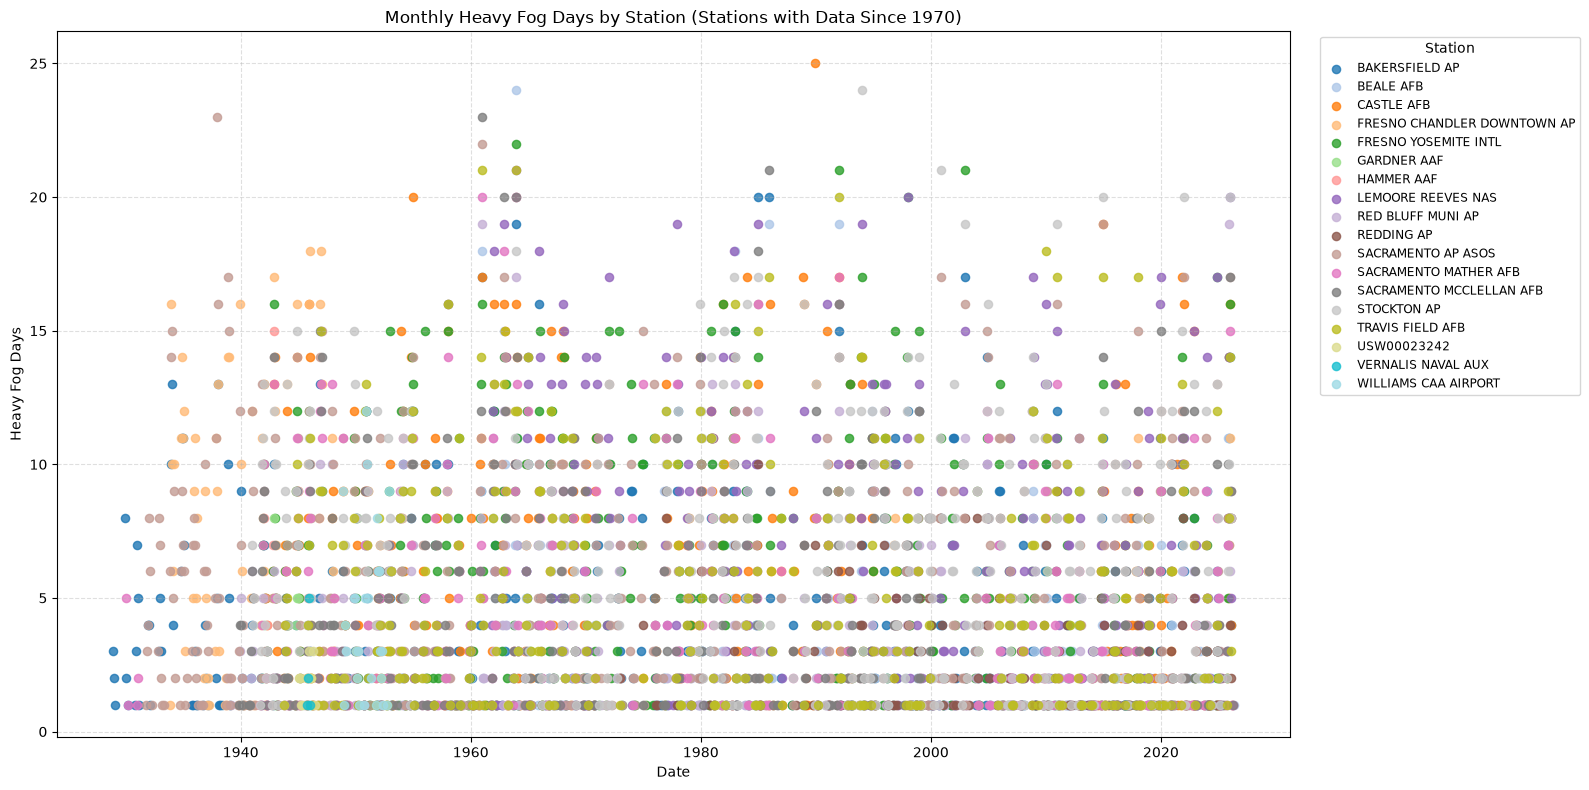

In [24]:
plot_df = (
    densefog_days_per_month_station[
        densefog_days_per_month_station["STATION"].isin(stations_pre1970)
    ].copy()
)

plot_df["date"] = pd.to_datetime(
    dict(year=plot_df["year"], month=plot_df["month"], day=1)
)

stations = plot_df["STATION"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

plt.figure(figsize=(16, 8))

for i, station in enumerate(stations):
    station_df = plot_df[plot_df["STATION"] == station].sort_values(["year", "month"])
    plt.scatter(
        station_df["date"],
        station_df["heavy_fog_days"],
        s=35,
        color=colors[i],
        alpha=0.8,
        label=station
    )

plt.title("Monthly Heavy Fog Days by Station (Stations with Data Since 1970)")
plt.xlabel("Date")
plt.ylabel("Heavy Fog Days")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
plt.tight_layout()
plt.show()

Now: Fog days per station per year and analysis


In [24]:
# pre = fog_days_year[fog_days_year['year'] <= 1980]
# post = fog_days_year[fog_days_year['year'] > 1980]


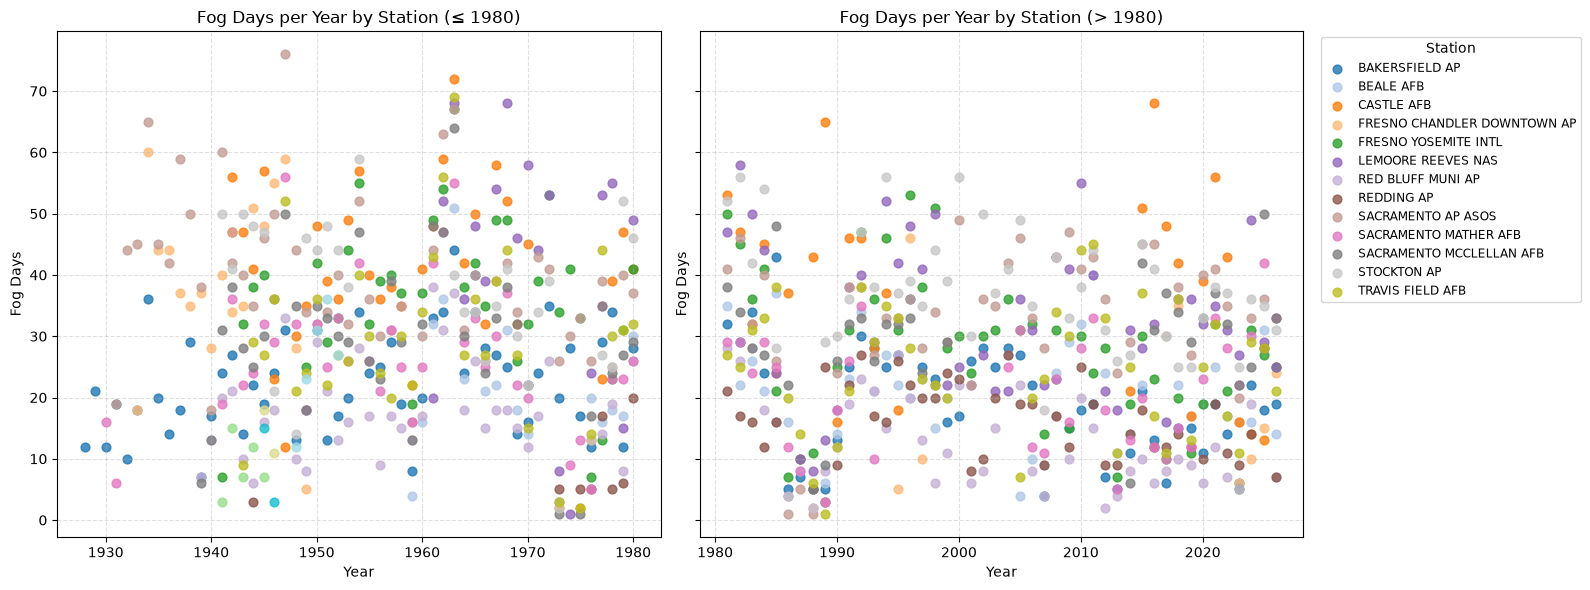

In [25]:
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [26]:
post1980_pre1970 = fog_days_year[
    (fog_days_year["year"] > 1980)
    & (fog_days_year["STATION"].isin(stations_pre1970))
].copy()

station_trend_stats_1980 = []

for station, station_df in post1980_pre1970.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_1980 = pd.DataFrame(station_trend_stats_1980).sort_values("p_value")

print("Post-1980 fog-day trend statistics for stations_pre1970:")
print(station_trend_stats_1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_pre1970 = station_trend_stats_1980[
    station_trend_stats_1980["trend_significant"]
]
print("\nStations with significant post-1980 fog-day trends:")
print(significant_post1980_pre1970[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 fog-day trend statistics for stations_pre1970:
                        STATION  n_obs  min_year  max_year     slope  \
6             RED BLUFF MUNI AP     43      1981      2026 -0.283140   
0                BAKERSFIELD AP     46      1981      2026 -0.268763   
4          FRESNO YOSEMITE INTL     46      1981      2026 -0.305890   
8            SACRAMENTO AP ASOS     46      1981      2026  0.252112   
7                    REDDING AP     44      1981      2026 -0.117509   
11                  STOCKTON AP     45      1981      2026 -0.143318   
10     SACRAMENTO MCCLELLAN AFB     31      1981      2026  0.116056   
1                     BEALE AFB     40      1981      2026 -0.094561   
9         SACRAMENTO MATHER AFB     36      1981      2026  0.109762   
2                    CASTLE AFB     28      1981      2026 -0.136979   
3   FRESNO CHANDLER DOWNTOWN AP      8      1995      2026 -0.136555   
5            LEMOORE REEVES NAS     46      1981      2026 -0.035399   
12     

This shows significant trends for Red Bluff Municipal Airport (9), Bakersfield Airport (1), and Fresno Yosemite Intl Airport (11)

Below is the analysis for dense fog:


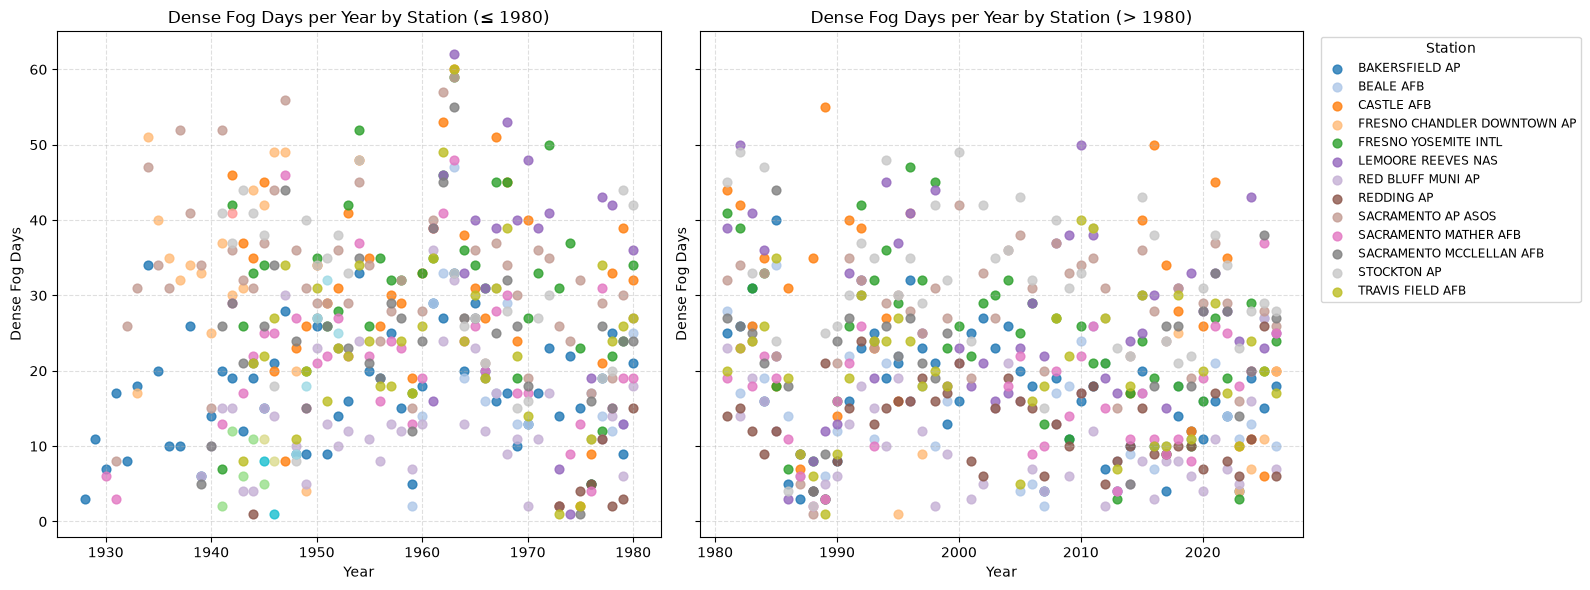

In [27]:
# Now the same with dense fog days per year for stations with data back to 1970
plot_stations_h = [st for st in stations_pre1970 if st in densefog_days_year['STATION'].unique()]
colors_h = plt.cm.tab20(np.linspace(0, 1, len(plot_stations_h)))
color_map_h = dict(zip(plot_stations_h, colors_h))

fog_pre1970_h = densefog_days_year[densefog_days_year['STATION'].isin(plot_stations_h)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations_h:
    station_df = fog_pre1970_h[fog_pre1970_h['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map_h[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map_h[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Dense Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Dense Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Dense Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [28]:
post1980_pre1970_h = densefog_days_year[
    (densefog_days_year["year"] > 1980)
    & (densefog_days_year["STATION"].isin(stations_pre1970))
].copy()

station_trend_stats_1980_h = []

for station, station_df in post1980_pre1970_h.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_1980_h.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_1980_h = pd.DataFrame(station_trend_stats_1980_h).sort_values("p_value")

print("Post-1980 heavy fog-day trend statistics for stations_pre1970:")
print(station_trend_stats_1980_h[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_pre1970_h = station_trend_stats_1980_h[
    station_trend_stats_1980_h["trend_significant"]
]
print("\nStations with significant post-1980 heavy fog-day trends:")
print(significant_post1980_pre1970_h[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 heavy fog-day trend statistics for stations_pre1970:
                        STATION  n_obs  min_year  max_year     slope  \
4          FRESNO YOSEMITE INTL     46      1981      2026 -0.252667   
6             RED BLUFF MUNI AP     43      1981      2026 -0.152390   
0                BAKERSFIELD AP     46      1981      2026 -0.194450   
1                     BEALE AFB     40      1981      2026 -0.136596   
7                    REDDING AP     44      1981      2026 -0.081522   
2                    CASTLE AFB     28      1981      2026 -0.201189   
9         SACRAMENTO MATHER AFB     36      1981      2026  0.107700   
8            SACRAMENTO AP ASOS     45      1981      2026  0.090520   
11                  STOCKTON AP     45      1981      2026 -0.087399   
3   FRESNO CHANDLER DOWNTOWN AP      8      1995      2026 -0.157563   
10     SACRAMENTO MCCLELLAN AFB     31      1981      2026  0.031697   
5            LEMOORE REEVES NAS     46      1981      2026  0.035338   
1

This shows significant heavy fog trends for Fresno Yosemite Intl Airport (11), Red Bluff Municipal Airport (9), and Bakersfield Airport (1)

Below: Finding average length of fog event per year

In [29]:
fog_events = CV_fog_rows.copy()
fog_events["DATE"] = pd.to_datetime(fog_events["DATE"])
fog_events = fog_events.sort_values(["STATION", "DATE"])

threshold = pd.Timedelta(hours=1.5)
fog_events["time_diff"] = fog_events.groupby("STATION")["DATE"].diff()
fog_events["new_event"] = fog_events["time_diff"].isna() | (fog_events["time_diff"] > threshold)
fog_events["event_id"] = fog_events.groupby("STATION")["new_event"].cumsum().astype(int)

fog_event_durations = (
    fog_events.groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "first"),
        end=("DATE", "last"),
        record_count=("DATE", "size")
    )
)

fog_event_durations["duration_hours"] = fog_event_durations["record_count"]
fog_event_durations["year"] = fog_event_durations["start"].dt.year

avg_fog_event_duration_by_station_year = (
    fog_event_durations
    .groupby(["STATION", "year"], as_index=False)["duration_hours"]
    .mean()
    .rename(columns={"duration_hours": "avg_event_duration_hours"})
    .sort_values(["STATION", "year"])
)

print(avg_fog_event_duration_by_station_year.head(20))

           STATION  year  avg_event_duration_hours
0   BAKERSFIELD AP  1928                  1.266667
1   BAKERSFIELD AP  1929                  1.416667
2   BAKERSFIELD AP  1930                  1.294118
3   BAKERSFIELD AP  1931                  1.714286
4   BAKERSFIELD AP  1932                  2.545455
5   BAKERSFIELD AP  1933                  2.675000
6   BAKERSFIELD AP  1934                  2.412698
7   BAKERSFIELD AP  1935                  2.450000
8   BAKERSFIELD AP  1936                  2.100000
9   BAKERSFIELD AP  1937                  1.424242
10  BAKERSFIELD AP  1938                  2.489796
11  BAKERSFIELD AP  1939                  2.333333
12  BAKERSFIELD AP  1940                  2.214286
13  BAKERSFIELD AP  1941                  2.121212
14  BAKERSFIELD AP  1942                  2.238095
15  BAKERSFIELD AP  1943                  2.000000
16  BAKERSFIELD AP  1944                  4.846154
17  BAKERSFIELD AP  1945                  2.625000
18  BAKERSFIELD AP  1946       

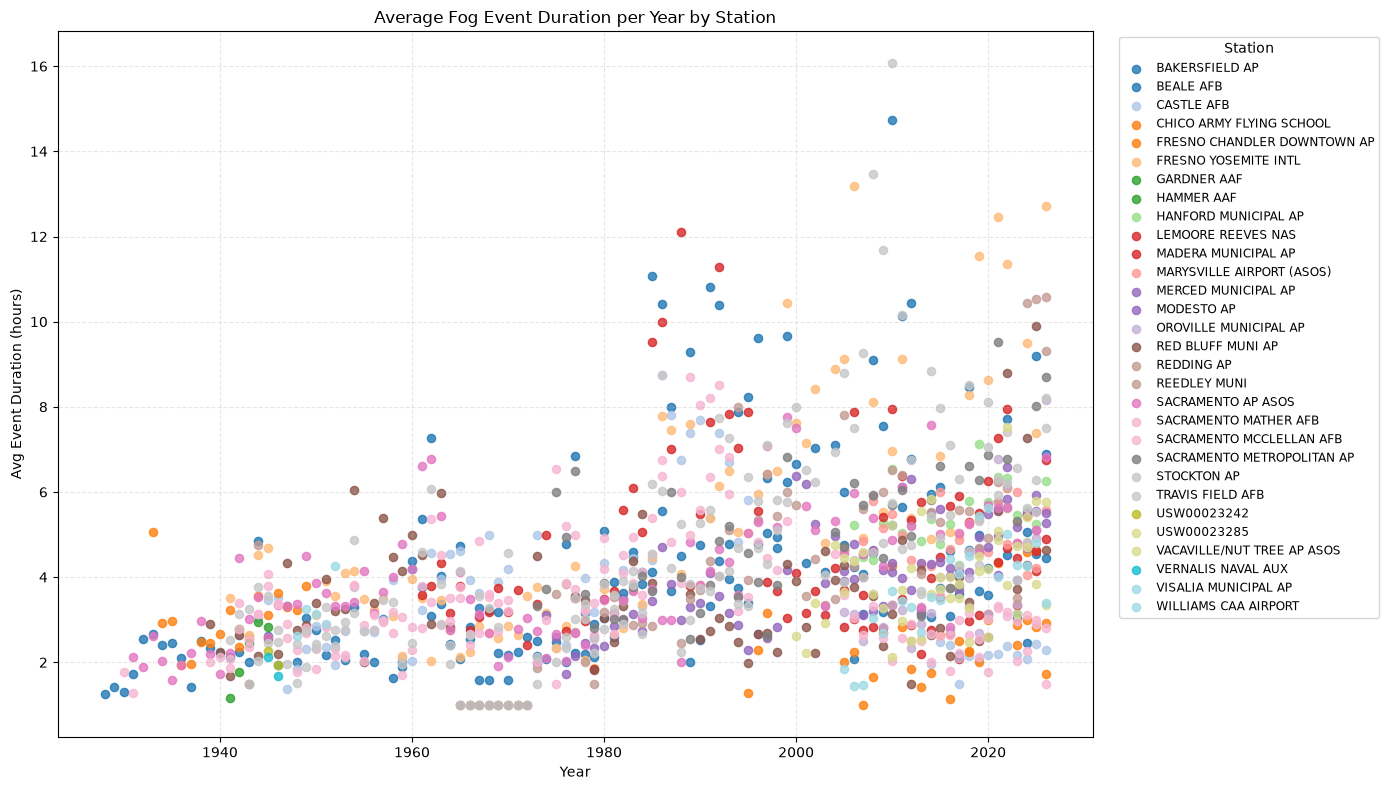

In [30]:
stations = avg_fog_event_duration_by_station_year['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

plt.figure(figsize=(14, 8))
for i, station in enumerate(stations):
    s_df = avg_fog_event_duration_by_station_year[
        avg_fog_event_duration_by_station_year['STATION'] == station
    ].sort_values('year')
    if s_df.empty:
        continue
    plt.scatter(
        s_df['year'],
        s_df['avg_event_duration_hours'],
        s=35,
        color=colors[i % len(colors)],
        alpha=0.8,
        label=station
    )

plt.title('Average Fog Event Duration per Year by Station')
plt.xlabel('Year')
plt.ylabel('Avg Event Duration (hours)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [30]:
def build_event_durations(df):
    df = df.copy()
    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.sort_values(["STATION", "DATE"]).reset_index(drop=True)

    threshold = pd.Timedelta(hours=1.5)
    df["time_diff"] = df.groupby("STATION")["DATE"].diff()
    df["new_event"] = df["time_diff"].isna() | (df["time_diff"] > threshold)
    df["event_id"] = df.groupby("STATION")["new_event"].cumsum().astype(int)

    events = (
        df.groupby(["STATION", "event_id"], as_index=False)
        .agg(
            start=("DATE", "min"),
            end=("DATE", "max"),
            records=("DATE", "size"),
        )
    )

    # Duration in hours for consecutive fog hours = number of consecutive records
    events["duration_hours"] = events["records"]
    events["year"] = events["start"].dt.year

    return events


fog_event_durations = build_event_durations(CV_fog_rows)
densefog_event_durations = build_event_durations(CV_densefog_rows)

avg_fog_event_duration_per_year = (
    fog_event_durations
    .groupby("year", as_index=False)["duration_hours"]
    .mean()
    .rename(columns={"duration_hours": "avg_event_duration_hours"})
    .assign(event_type="fog")
)

avg_densefog_event_duration_per_year = (
    densefog_event_durations
    .groupby("year", as_index=False)["duration_hours"]
    .mean()
    .rename(columns={"duration_hours": "avg_event_duration_hours"})
    .assign(event_type="dense_fog")
)

avg_event_duration_per_year = pd.concat(
    [avg_fog_event_duration_per_year, avg_densefog_event_duration_per_year],
    ignore_index=True
)

print("Fog event durations (first rows):")
print(fog_event_durations.head())

print("\nDense fog event durations (first rows):")
print(densefog_event_durations.head())

print("\nAverage event duration per year:")
print(avg_event_duration_per_year.head())

Fog event durations (first rows):
       STATION  event_id               start                 end  records  \
0  USI0000KO32         1 2018-10-05 06:10:00 2018-10-05 06:10:00        1   
1  USI0000KO32         2 2018-11-24 04:55:00 2018-11-24 04:55:00        1   
2  USI0000KO32         3 2018-11-25 05:15:00 2018-11-25 09:35:00        9   
3  USI0000KO32         4 2018-11-25 22:35:00 2018-11-26 02:15:00        8   
4  USI0000KO32         5 2018-11-26 04:55:00 2018-11-26 06:15:00        3   

   duration_hours  year  
0               1  2018  
1               1  2018  
2               9  2018  
3               8  2018  
4               3  2018  

Dense fog event durations (first rows):
       STATION  event_id               start                 end  records  \
0  USI0000KO32         1 2018-11-25 05:15:00 2018-11-25 08:55:00        7   
1  USI0000KO32         2 2018-11-25 22:35:00 2018-11-25 23:55:00        2   
2  USI0000KO32         3 2018-11-26 01:35:00 2018-11-26 02:15:00        3  

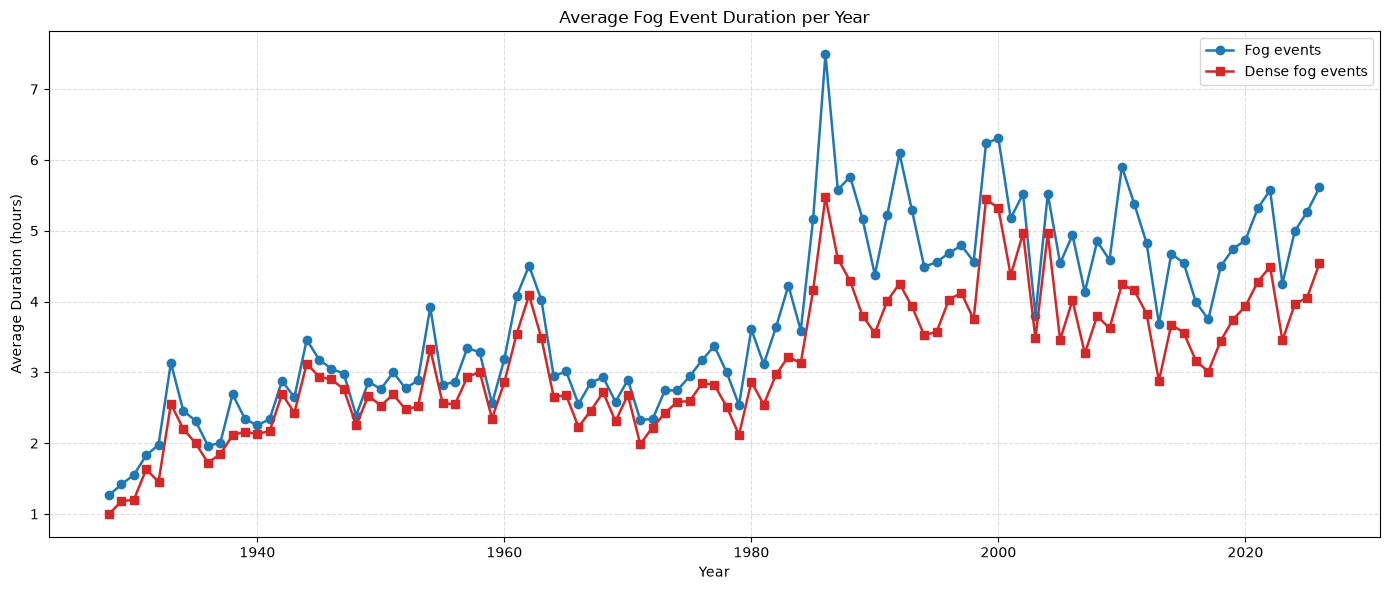

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    avg_fog_event_duration_per_year["year"],
    avg_fog_event_duration_per_year["avg_event_duration_hours"],
    marker="o",
    linestyle="-",
    linewidth=1.8,
    color="tab:blue",
    label="Fog events"
)

plt.plot(
    avg_densefog_event_duration_per_year["year"],
    avg_densefog_event_duration_per_year["avg_event_duration_hours"],
    marker="s",
    linestyle="-",
    linewidth=1.8,
    color="tab:red",
    label="Dense fog events"
)

plt.title("Average Fog Event Duration per Year")
plt.xlabel("Year")
plt.ylabel("Average Duration (hours)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Linear trend analysis of average event duration by year using statsmodels

# Fit OLS models for fog and dense fog
fog_duration_model = smf.ols(
    "avg_event_duration_hours ~ year",
    data=avg_fog_event_duration_per_year
).fit()

densefog_duration_model = smf.ols(
    "avg_event_duration_hours ~ year",
    data=avg_densefog_event_duration_per_year
).fit()

print("Fog event duration trend (OLS)")
print(fog_duration_model.summary())

print("\nDense fog event duration trend (OLS)")
print(densefog_duration_model.summary())

# Summarize key trend statistics
trend_summary = pd.DataFrame({
    "event_type": ["fog", "dense_fog"],
    "slope_hours_per_year": [
        fog_duration_model.params["year"],
        densefog_duration_model.params["year"]
    ],
    "p_value": [
        fog_duration_model.pvalues["year"],
        densefog_duration_model.pvalues["year"]
    ],
    "r_squared": [
        fog_duration_model.rsquared,
        densefog_duration_model.rsquared
    ],
})
trend_summary["significant"] = trend_summary["p_value"] < 0.05

print("\nTrend comparison:")
print(trend_summary)

Fog event duration trend (OLS)
                               OLS Regression Results                               
Dep. Variable:     avg_event_duration_hours   R-squared:                       0.613
Model:                                  OLS   Adj. R-squared:                  0.609
Method:                       Least Squares   F-statistic:                     153.6
Date:                      Sun, 28 Jun 2026   Prob (F-statistic):           1.04e-21
Time:                              21:09:55   Log-Likelihood:                -117.79
No. Observations:                        99   AIC:                             239.6
Df Residuals:                            97   BIC:                             244.8
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

Post-1980 fog event durations (first rows):
       STATION  event_id               start                 end  records  \
0  USI0000KO32         1 2018-10-05 06:10:00 2018-10-05 06:10:00        1   
1  USI0000KO32         2 2018-11-24 04:55:00 2018-11-24 04:55:00        1   
2  USI0000KO32         3 2018-11-25 05:15:00 2018-11-25 09:35:00        9   
3  USI0000KO32         4 2018-11-25 22:35:00 2018-11-26 02:15:00        8   
4  USI0000KO32         5 2018-11-26 04:55:00 2018-11-26 06:15:00        3   

   duration_hours  year  
0               1  2018  
1               1  2018  
2               9  2018  
3               8  2018  
4               3  2018  

Post-1980 dense fog event durations (first rows):
       STATION  event_id               start                 end  records  \
0  USI0000KO32         1 2018-11-25 05:15:00 2018-11-25 08:55:00        7   
1  USI0000KO32         2 2018-11-25 22:35:00 2018-11-25 23:55:00        2   
2  USI0000KO32         3 2018-11-26 01:35:00 2018-11-26

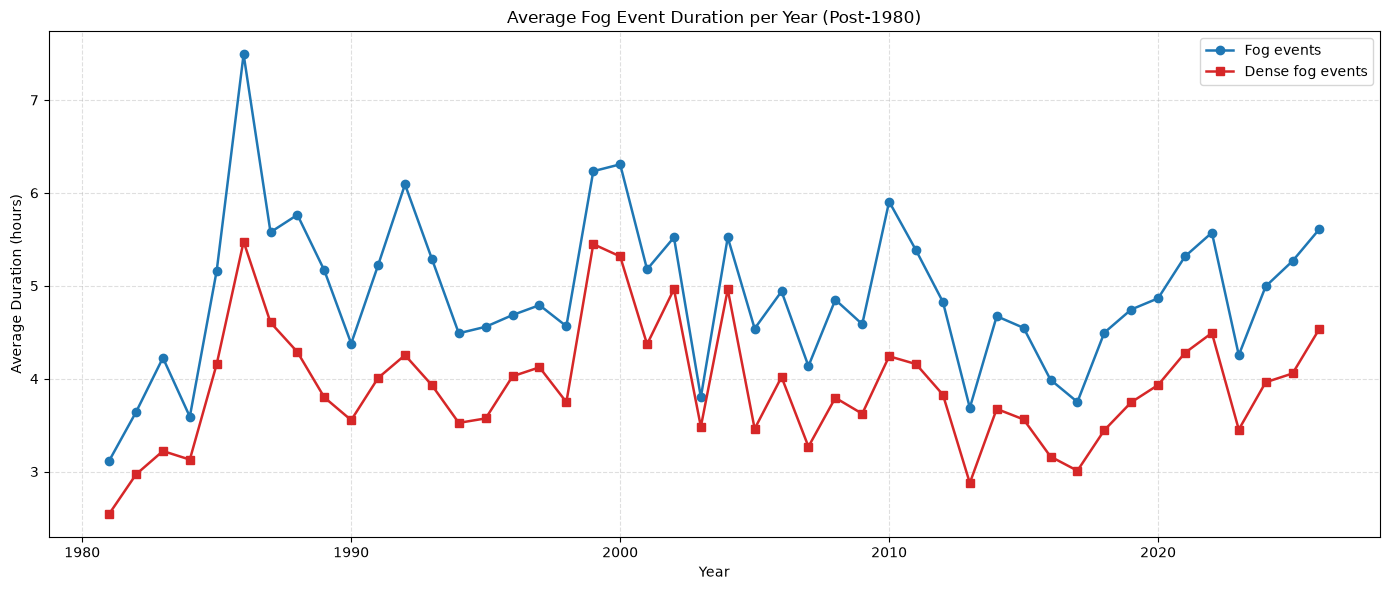

Fog event duration trend (OLS, post-1980)
                               OLS Regression Results                               
Dep. Variable:     avg_event_duration_hours   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                 -0.023
Method:                       Least Squares   F-statistic:                  0.002685
Date:                      Sun, 28 Jun 2026   Prob (F-statistic):              0.959
Time:                              21:23:44   Log-Likelihood:                -56.164
No. Observations:                        46   AIC:                             116.3
Df Residuals:                            44   BIC:                             120.0
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [ ]:
// # Post-1980 event-duration analysis for fog and dense fog

fog_event_durations_post1980 = (
    fog_event_durations[fog_event_durations["year"] > 1980].copy()
)

densefog_event_durations_post1980 = (
    densefog_event_durations[densefog_event_durations["year"] > 1980].copy()
)

avg_fog_event_duration_per_year_post1980 = (
    fog_event_durations_post1980
    .groupby("year", as_index=False)["duration_hours"]
    .mean()
    .rename(columns={"duration_hours": "avg_event_duration_hours"})
    .assign(event_type="fog")
)

avg_densefog_event_duration_per_year_post1980 = (
    densefog_event_durations_post1980
    .groupby("year", as_index=False)["duration_hours"]
    .mean()
    .rename(columns={"duration_hours": "avg_event_duration_hours"})
    .assign(event_type="dense_fog")
)

avg_event_duration_per_year_post1980 = pd.concat(
    [avg_fog_event_duration_per_year_post1980, avg_densefog_event_duration_per_year_post1980],
    ignore_index=True
)

print("Post-1980 fog event durations (first rows):")
print(fog_event_durations_post1980.head())

print("\nPost-1980 dense fog event durations (first rows):")
print(densefog_event_durations_post1980.head())

print("\nAverage post-1980 event duration per year:")
print(avg_event_duration_per_year_post1980.head())

plt.figure(figsize=(14, 6))

plt.plot(
    avg_fog_event_duration_per_year_post1980["year"],
    avg_fog_event_duration_per_year_post1980["avg_event_duration_hours"],
    marker="o",
    linestyle="-",
    linewidth=1.8,
    color="tab:blue",
    label="Fog events"
)

plt.plot(
    avg_densefog_event_duration_per_year_post1980["year"],
    avg_densefog_event_duration_per_year_post1980["avg_event_duration_hours"],
    marker="s",
    linestyle="-",
    linewidth=1.8,
    color="tab:red",
    label="Dense fog events"
)

plt.title("Average Fog Event Duration per Year (Post-1980)")
plt.xlabel("Year")
plt.ylabel("Average Duration (hours)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

fog_duration_model_post1980 = smf.ols(
    "avg_event_duration_hours ~ year",
    data=avg_fog_event_duration_per_year_post1980
).fit()

densefog_duration_model_post1980 = smf.ols(
    "avg_event_duration_hours ~ year",
    data=avg_densefog_event_duration_per_year_post1980
).fit()

print("Fog event duration trend (OLS, post-1980)")
print(fog_duration_model_post1980.summary())

print("\nDense fog event duration trend (OLS, post-1980)")
print(densefog_duration_model_post1980.summary())

trend_summary_post1980 = pd.DataFrame({
    "event_type": ["fog", "dense_fog"],
    "slope_hours_per_year": [
        fog_duration_model_post1980.params["year"],
        densefog_duration_model_post1980.params["year"]
    ],
    "p_value": [
        fog_duration_model_post1980.pvalues["year"],
        densefog_duration_model_post1980.pvalues["year"]
    ],
    "r_squared": [
        fog_duration_model_post1980.rsquared,
        densefog_duration_model_post1980.rsquared
    ],
})
trend_summary_post1980["significant"] = trend_summary_post1980["p_value"] < 0.05

print("\nPost-1980 trend comparison:")
print(trend_summary_post1980)

The code works up to here
_____________________
____________________

In [48]:
plt.figure(figsize=(14, 8))

stations = fog_days_per_year_by_station['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_per_year_by_station[fog_days_per_year_by_station['STATION'] == station]
    plt.scatter(
        station_df['year'],
        station_df['fog_days'],
        color=colors[i],
        label=station,
        s=40,
        alpha=0.75
    )

plt.title('Fog Days per Year by Station')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

NameError: name 'fog_days_per_year_by_station' is not defined

<Figure size 1400x800 with 0 Axes>

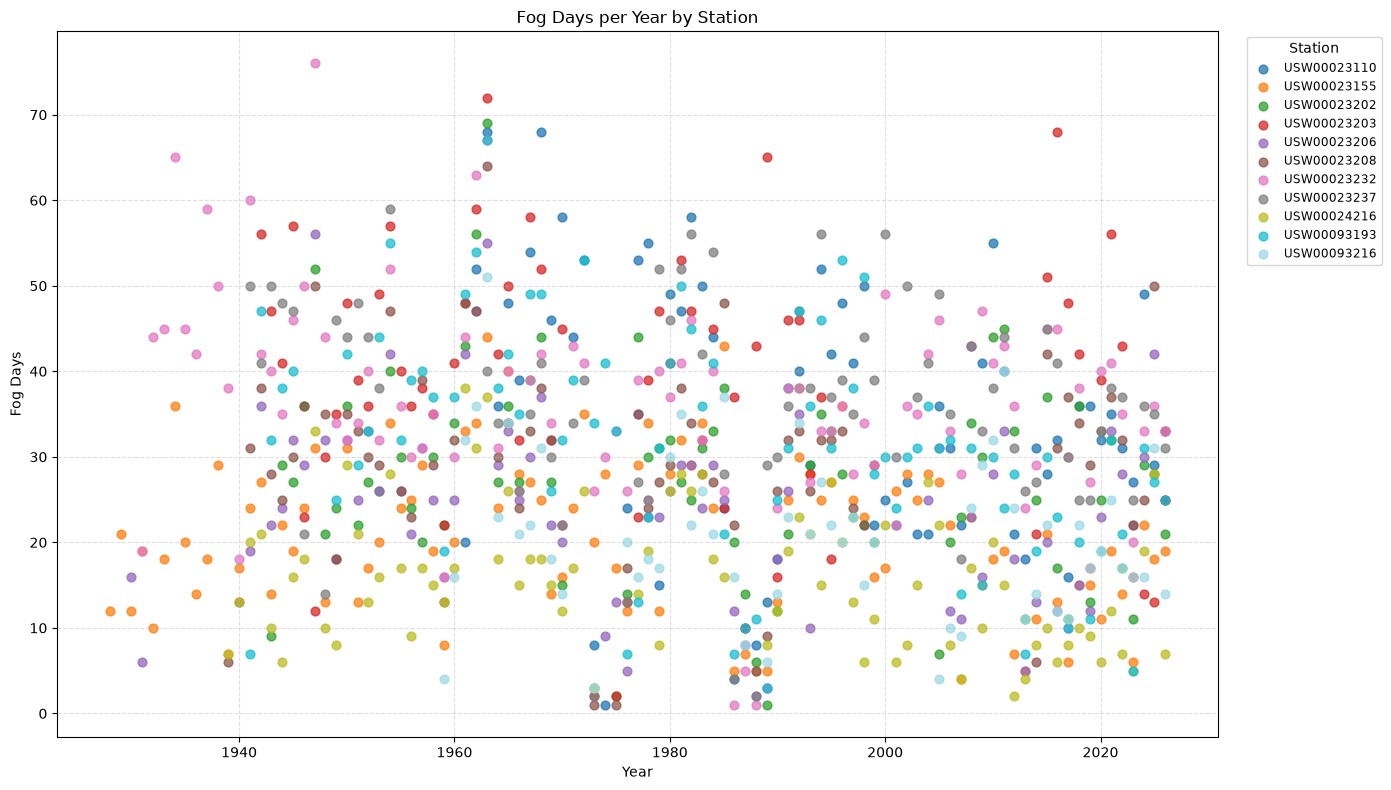

In [14]:
plt.figure(figsize=(14, 8))

stations = fog_days_per_year_by_station['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_per_year_by_station[fog_days_per_year_by_station['STATION'] == station]
    plt.scatter(
        station_df['year'],
        station_df['fog_days'],
        color=colors[i],
        label=station,
        s=40,
        alpha=0.75
    )

plt.title('Fog Days per Year by Station')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

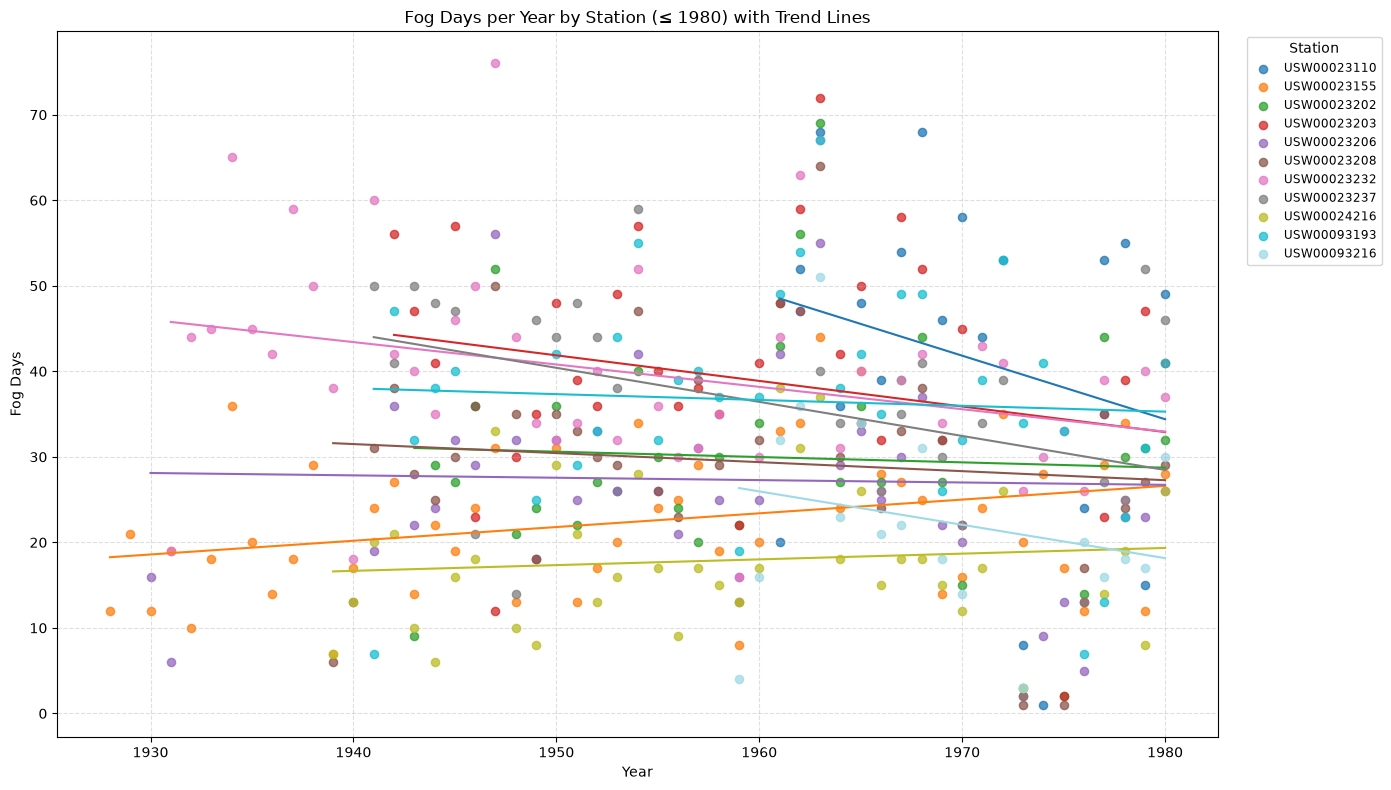

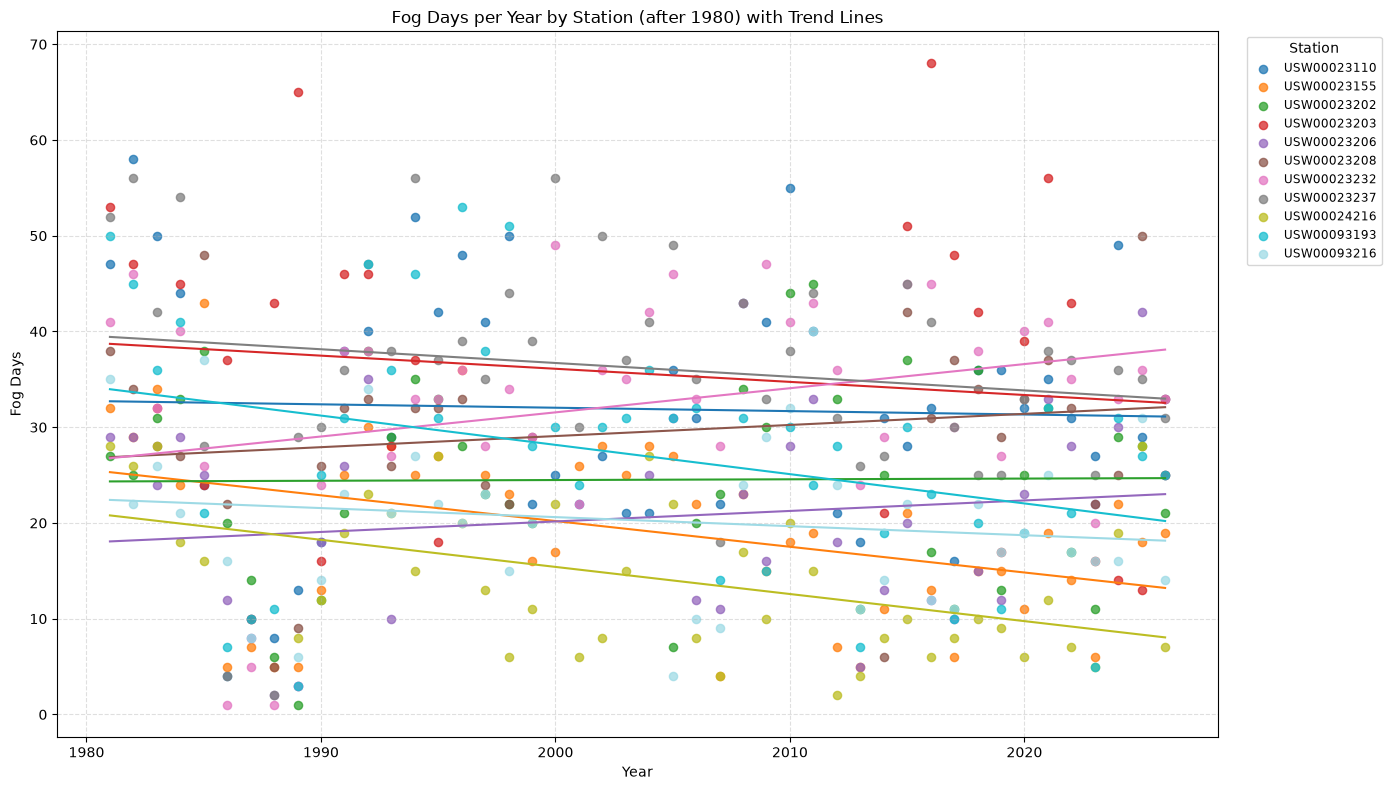

In [15]:
fog_days_pre1980 = fog_days_per_year_by_station[fog_days_per_year_by_station['year'] <= 1980]
fog_days_post1980 = fog_days_per_year_by_station[fog_days_per_year_by_station['year'] > 1980]

plt.figure(figsize=(14, 8))
stations_pre = fog_days_pre1980['STATION'].unique()
colors_pre = plt.cm.tab20(np.linspace(0, 1, len(stations_pre)))

for i, station in enumerate(stations_pre):
    station_df = fog_days_pre1980[fog_days_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors_pre[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors_pre[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

plt.figure(figsize=(14, 8))
stations_post = fog_days_post1980['STATION'].unique()
colors_post = plt.cm.tab20(np.linspace(0, 1, len(stations_post)))

for i, station in enumerate(stations_post):
    station_df = fog_days_post1980[fog_days_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors_post[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors_post[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

In [54]:
post_fit_stats = []

for station, station_df in fog_days_post1980.groupby('STATION'):
    station_df = station_df.sort_values('year')
    if len(station_df) < 2:
        continue

    x = station_df['year'].astype(float)
    y = station_df['fog_days'].astype(float)

    res = stats.linregress(x, y, alternative='more')
    post_fit_stats.append({
        'STATION': station,
        'slope': res.slope,
        'intercept': res.intercept,
        'r_squared': res.rvalue ** 2,
        'p_value': res.pvalue,
        'stderr': res.stderr,
        'n_obs': len(station_df),
    })

post_fit_stats_df = pd.DataFrame(post_fit_stats).sort_values('r_squared', ascending=False)
print(post_fit_stats_df[['STATION', 'slope', 'r_squared', 'p_value', 'n_obs']])

NameError: name 'fog_days_post1980' is not defined

fog_hours_pre1970_stations: (934, 3)
       STATION  year  fog_hours
0  USM00074917  1941          7
1  USM00074917  1942         46
2  USM00074917  1943         22
3  USM00074917  1944         47
4  USM00074917  1945         31


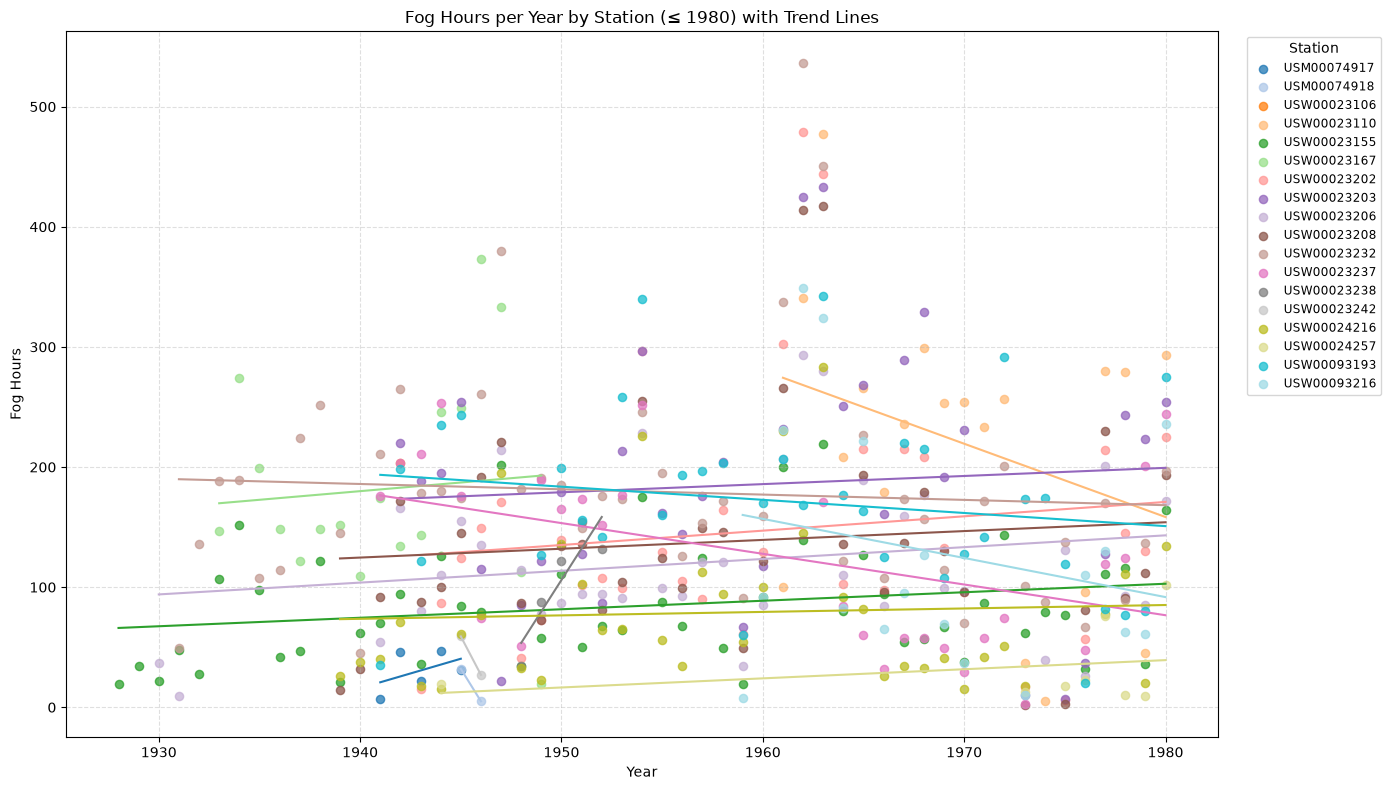

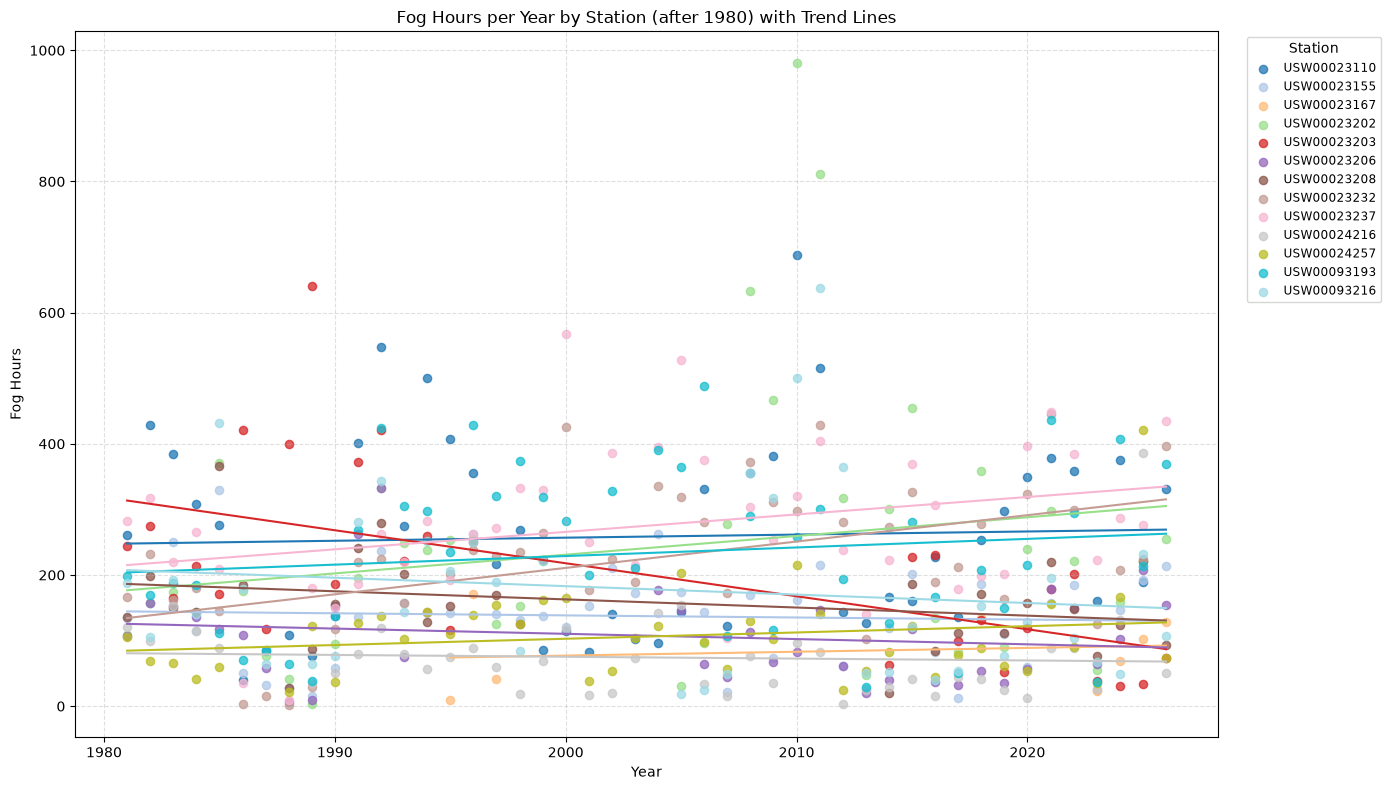

In [19]:
fog_hours_pre1970_stations = (
    CV_fog_rows[CV_fog_rows['STATION'].isin(stations_pre1970)]
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_hours')
    .sort_values(['STATION', 'year'])
)

print("fog_hours_pre1970_stations:", fog_hours_pre1970_stations.shape)
print(fog_hours_pre1970_stations.head())

fog_hours_pre1980 = fog_hours_pre1970_stations[fog_hours_pre1970_stations['year'] <= 1980]
fog_hours_post1980 = fog_hours_pre1970_stations[fog_hours_pre1970_stations['year'] > 1980]

plt.figure(figsize=(14, 8))
stations = fog_hours_pre1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_hours_pre1980[fog_hours_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_hours'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x, slope * x + intercept, color=colors[i], linewidth=1.5)

plt.title('Fog Hours per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Hours')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

plt.figure(figsize=(14, 8))
stations = fog_hours_post1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_hours_post1980[fog_hours_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_hours'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=35, alpha=0.75)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x, slope * x + intercept, color=colors[i], linewidth=1.5)

plt.title('Fog Hours per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Hours')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()


In [20]:

post_hours_fit_stats = []

for station, station_df in fog_hours_post1980.groupby('STATION'):
    station_df = station_df.sort_values('year')
    x = station_df['year'].astype(float)
    y = station_df['fog_hours'].astype(float)

    if len(station_df) >= 2:
        res = stats.linregress(x, y)
        post_hours_fit_stats.append({
            'STATION': station,
            'slope': res.slope,
            'intercept': res.intercept,
            'r_squared': res.rvalue ** 2,
            'p_value': res.pvalue,
            'stderr': res.stderr,
            'n_obs': len(station_df),
        })

post_hours_fit_stats_df = pd.DataFrame(post_hours_fit_stats).sort_values('r_squared', ascending=False)
print(post_hours_fit_stats_df[['STATION', 'slope', 'intercept', 'r_squared', 'p_value', 'n_obs']])

        STATION     slope     intercept  r_squared   p_value  n_obs
4   USW00023203 -5.032227  10282.367733   0.349218  0.000929     28
7   USW00023232  4.020845  -7830.893185   0.256665  0.000327     46
8   USW00023237  2.659531  -5053.345493   0.098083  0.036189     45
6   USW00023208 -1.238365   2639.529401   0.072994  0.141578     31
3   USW00023202  2.852528  -5474.073959   0.041343  0.202293     41
10  USW00024257  0.956864  -1810.907670   0.034473  0.227564     44
5   USW00023206 -0.799077   1708.477556   0.027644  0.332466     36
11  USW00093193  1.309035  -2389.173050   0.020981  0.336833     46
2   USW00023167  0.584734  -1092.319328   0.020486  0.735275      8
12  USW00093216 -1.285783   2754.555837   0.017004  0.422556     40
9   USW00024216 -0.280333    636.016182   0.003324  0.713435     43
1   USW00023155 -0.319581    777.584150   0.003276  0.705547     46
0   USW00023110  0.472402   -687.892384   0.001840  0.777139     46


In [21]:
station_avg_fog_days = (
    fog_days_year
    .groupby('STATION', as_index=False)['fog_days']
    .mean()
    .rename(columns={'fog_days': 'avg_fog_days_per_year'})
    .sort_values('avg_fog_days_per_year', ascending=False)
)

print(station_avg_fog_days)

yearly_avg_fog_days = (
    fog_days_year
    .groupby('year', as_index=False)['fog_days']
    .mean()
    .rename(columns={'fog_days': 'avg_fog_days_per_station'})
)

plt.figure(figsize=(14, 6))
plt.bar(
    station_avg_fog_days['STATION'],
    station_avg_fog_days['avg_fog_days_per_year'],
    color='tab:blue',
    alpha=0.8
)
plt.xticks(rotation=90)
plt.title('Average Fog Days per Station per Year')
plt.xlabel('Station')
plt.ylabel('Average Fog Days per Year')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(
    yearly_avg_fog_days['year'],
    yearly_avg_fog_days['avg_fog_days_per_station'],
    marker='o',
    linestyle='-',
    color='tab:orange'
)
plt.title('Average Fog Days per Station by Year')
plt.xlabel('Year')
plt.ylabel('Average Fog Days per Station')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

NameError: name 'fog_days_year' is not defined

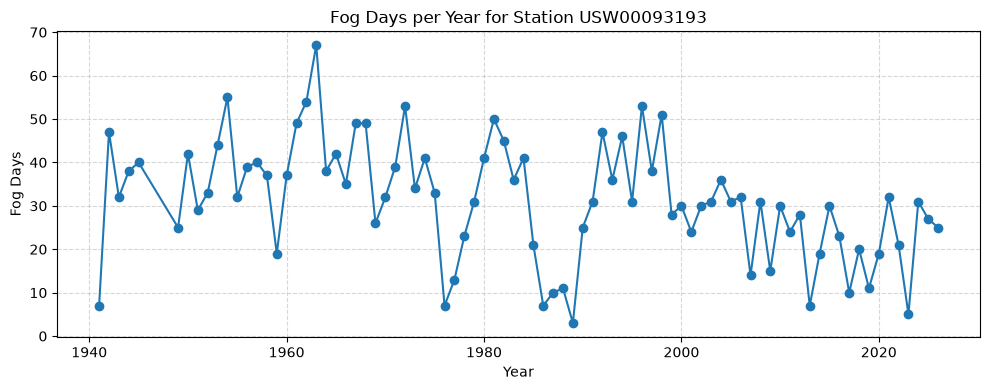

In [16]:
station = 'USW00093193'
station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')

plt.figure(figsize=(10, 4))
plt.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-')
plt.title(f'Fog Days per Year for Station {station}')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
fog_hours_year = CV_fog_rows.groupby(['STATION', 'year']).size().reset_index(name='fog_hours')

fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_days')
)

fog_avg_hours_per_day = fog_hours_year.merge(fog_days_year, on=['STATION', 'year'])
fog_avg_hours_per_day['avg_fog_hours_per_day'] = (
    fog_avg_hours_per_day['fog_hours'] / fog_avg_hours_per_day['fog_days']
)

fog_avg_hours_per_day = fog_avg_hours_per_day.sort_values(['STATION', 'year']).reset_index(drop=True)
print(fog_avg_hours_per_day.head(20))

        STATION  year  fog_hours  fog_days  avg_fog_hours_per_day
0   USI0000KO32  2018         43        10               4.300000
1   USI0000KO32  2023        173        22               7.863636
2   USI0000KO32  2024        303        38               7.973684
3   USI0000KO32  2025        240        36               6.666667
4   USI0000KO32  2026        298        23              12.956522
5   USM00074917  1941          7         3               2.333333
6   USM00074917  1942         46        15               3.066667
7   USM00074917  1943         22         7               3.142857
8   USM00074917  1944         47        12               3.916667
9   USM00074917  1945         31         7               4.428571
10  USM00074918  1945         32        15               2.133333
11  USM00074918  1946          5         3               1.666667
12  USW00023106  1942        203        47               4.319149
13  USW00023110  1961        100        20               5.000000
14  USW000

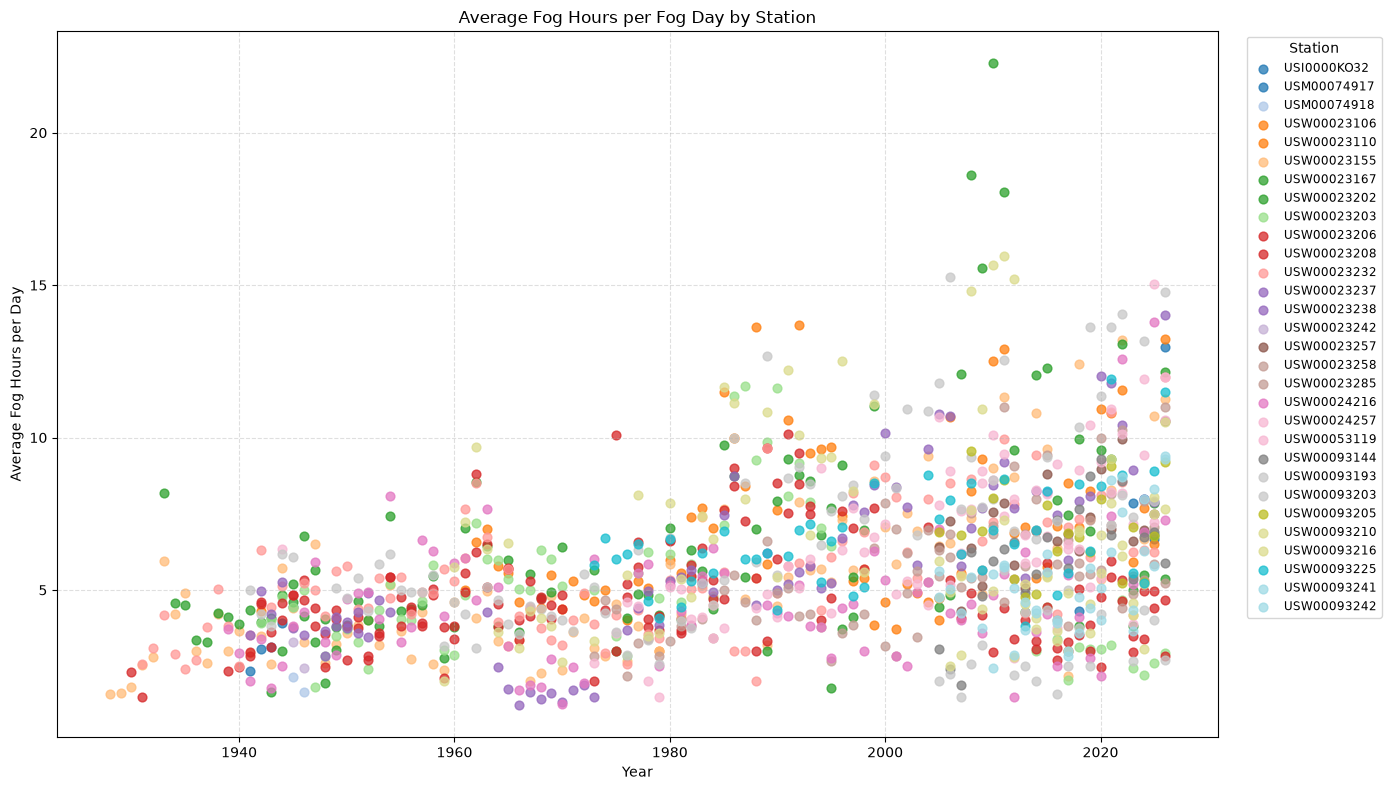

In [14]:
plt.figure(figsize=(14, 8))

stations = fog_avg_hours_per_day['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_avg_hours_per_day[fog_avg_hours_per_day['STATION'] == station].sort_values('year')
    plt.scatter(
        station_df['year'],
        station_df['avg_fog_hours_per_day'],
        color=colors[i % len(colors)],
        label=station,
        s=40,
        alpha=0.75
    )

plt.title('Average Fog Hours per Fog Day by Station')
plt.xlabel('Year')
plt.ylabel('Average Fog Hours per Day')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

In [29]:
CVfog_rows['DATE'] = pd.to_datetime(CVfog_rows['DATE'])
CVfog_rows['year'] = CVfog_rows['DATE'].dt.year
CVfog_rows['month'] = CVfog_rows['DATE'].dt.month

monthly_heavy_fog_days = (
    CVfog_rows
    .groupby(['STATION', 'year', 'month'], as_index=False)
    ['MonthlyNumberDaysWithHeavyFog']
    .sum()
    .rename(columns={'MonthlyNumberDaysWithHeavyFog': 'heavy_fog_days'})
)

print(monthly_heavy_fog_days.head())

       STATION  year  month  heavy_fog_days
0  USW00023110  1965      1            15.0
1  USW00023110  1965      2             1.0
2  USW00023110  1965      4             1.0
3  USW00023110  1965     11             7.0
4  USW00023110  1965     12            18.0


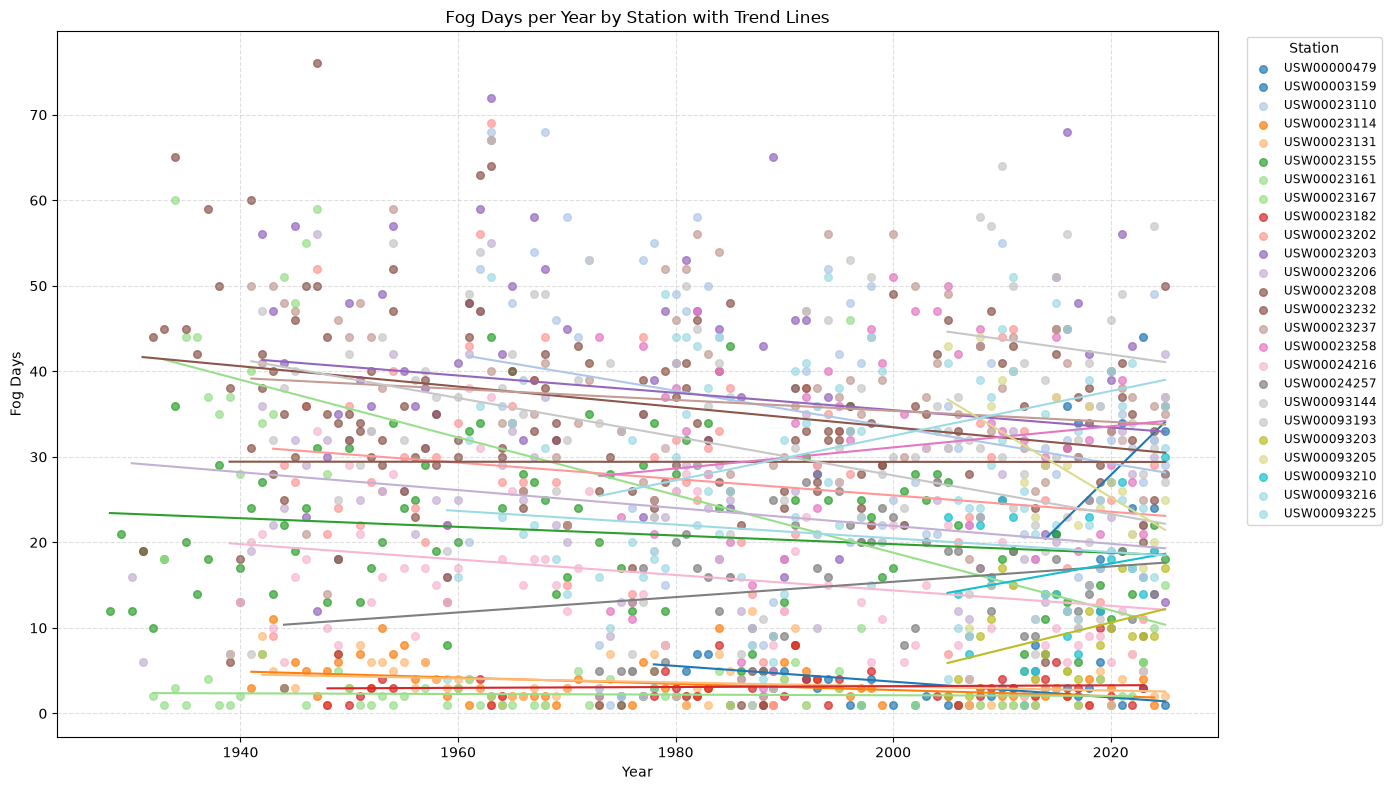

In [33]:
plt.figure(figsize=(14, 8))

stations = fog_days_year['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_year[fog_days_year['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i % len(colors)], label=station, s=30, alpha=0.7)

    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i % len(colors)], linewidth=1.5)

plt.title('Fog Days per Year by Station with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

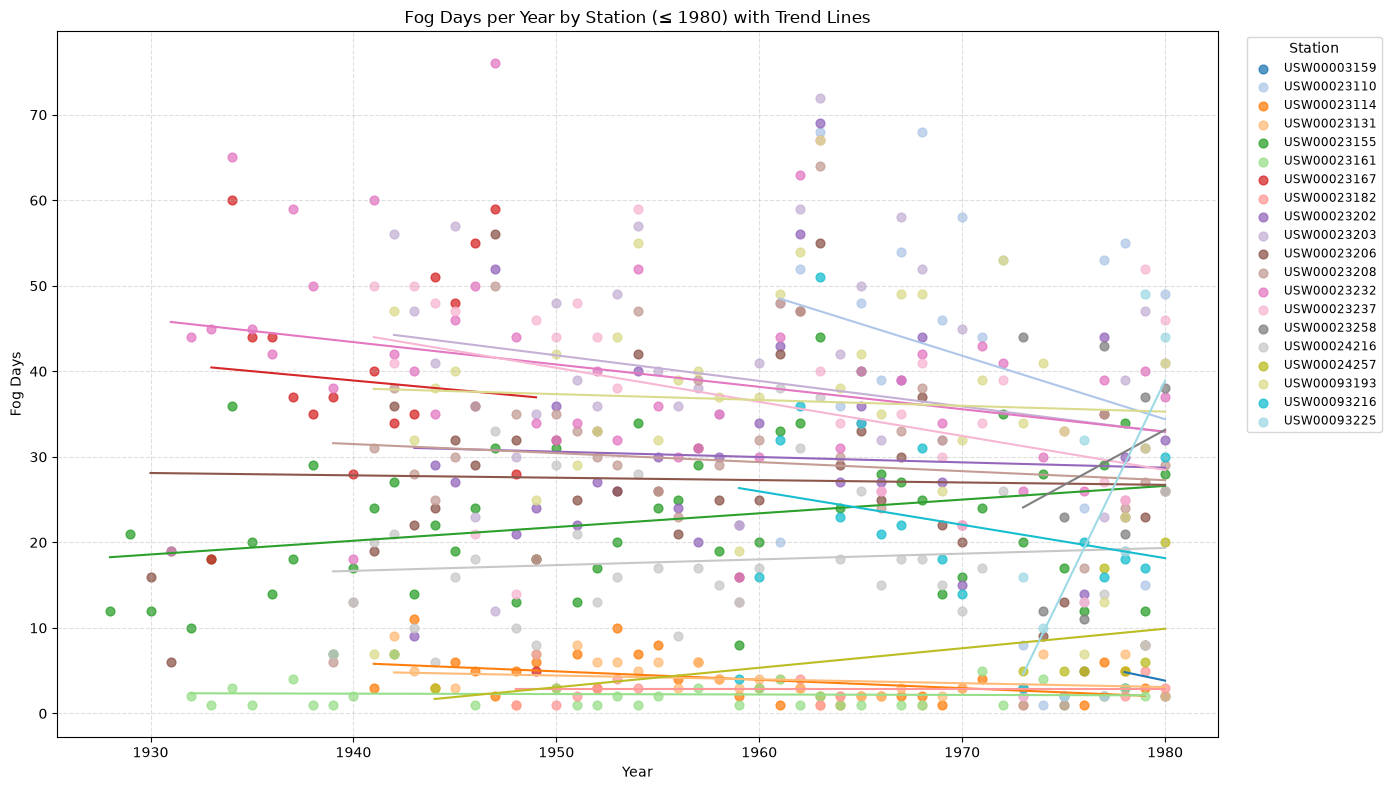

In [34]:
fog_days_pre1980 = fog_days_year[fog_days_year['year'] <= 1980]

plt.figure(figsize=(14, 8))
stations = fog_days_pre1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_pre1980[fog_days_pre1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i], label=station, s=40, alpha=0.75)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i], linewidth=1.5)

plt.title('Fog Days per Year by Station (≤ 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

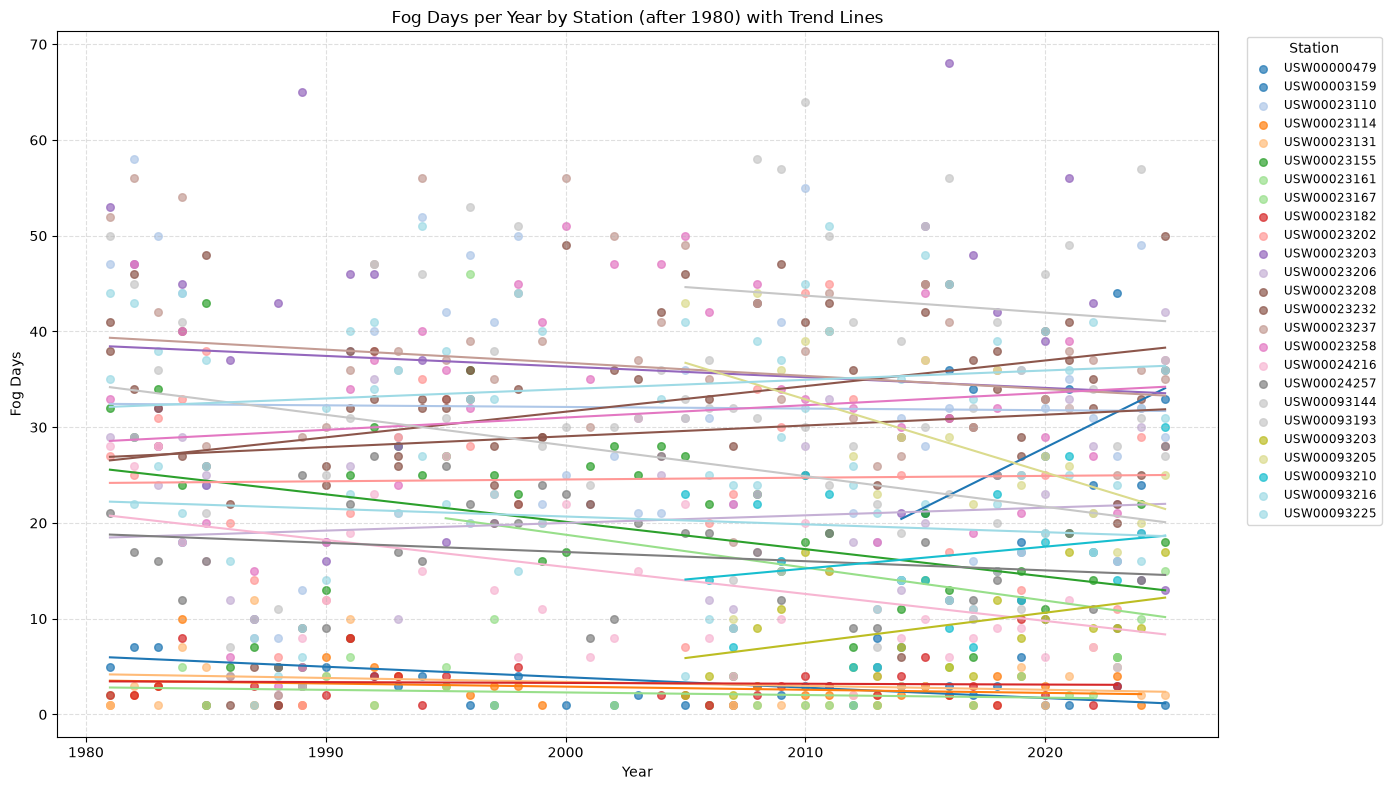

In [35]:
fog_days_post1980 = fog_days_year[fog_days_year['year'] > 1980]

plt.figure(figsize=(14, 8))

stations = fog_days_post1980['STATION'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(stations)))

for i, station in enumerate(stations):
    station_df = fog_days_post1980[fog_days_post1980['STATION'] == station].sort_values('year')
    x = station_df['year'].astype(int).to_numpy()
    y = station_df['fog_days'].to_numpy()

    plt.scatter(x, y, color=colors[i % len(colors)], label=station, s=30, alpha=0.7)

    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x + b, color=colors[i % len(colors)], linewidth=1.5)

plt.title('Fog Days per Year by Station (after 1980) with Trend Lines')
plt.xlabel('Year')
plt.ylabel('Fog Days')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()

In [29]:
fog_hours_per_year = CV_fog_rows.groupby('year').size().rename('fog_hours')
fog_days_per_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby('year')
    .size()
    .rename('fog_days')
)

fog_summary = pd.concat([fog_hours_per_year, fog_days_per_year], axis=1).reset_index()
print(fog_summary)

densefog_hours_per_year = CV_densefog_rows.groupby('year').size().rename('densefog_hours')
densefog_days_per_year = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby('year')
    .size()
    .rename('densefog_days')
)

densefog_summary = pd.concat([densefog_hours_per_year, densefog_days_per_year], axis=1).reset_index()
print(densefog_summary)

    year  fog_hours  fog_days
0   1928         19        12
1   1929         34        21
2   1930         59        28
3   1931        106        44
4   1932        169        56
..   ...        ...       ...
93  2021       5027       614
94  2022       3833       476
95  2023       1737       362
96  2024       3400       524
97  2025       4365       598

[98 rows x 3 columns]
    year  densefog_hours  densefog_days
0   1928               3              3
1   1929              13             11
2   1930              18             13
3   1931              62             28
4   1932              61             34
..   ...             ...            ...
93  2021            3506            529
94  2022            2684            400
95  2023            1066            275
96  2024            2223            419
97  2025            2689            480

[98 rows x 3 columns]


In [17]:
threshold = pd.Timedelta(hours=1.5)

for df in (CV_fog_rows, CV_densefog_rows):
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.sort_values(['STATION', 'DATE'], inplace=True)
    df['time_diff'] = df.groupby('STATION')['DATE'].diff()
    df['new_event'] = df['time_diff'] > threshold
    df['event_id'] = df.groupby('STATION')['new_event'].cumsum().astype(int)
    df['station_event_id'] = df['STATION'] + '_' + df['event_id'].astype(str)

CV_fog_events = (
    CV_fog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        fog_hours=lambda x: x['records']
    )
    .reset_index()
)

CV_densefog_events = (
    CV_densefog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        densefog_hours=lambda x: x['records']
    )
    .reset_index()
)

print("Fog events:", CV_fog_events.shape)
print("Dense fog events:", CV_densefog_events.shape)
print(CV_fog_events.head())
print(CV_densefog_events.head())

Fog events: (45494, 7)
Dense fog events: (36777, 7)
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 09:55:00 2014-11-13 12:35:00        6   
1  USW00000479         1 2014-11-14 08:35:00 2014-11-14 08:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:35:00        2   
3  USW00000479         3 2014-11-22 00:15:00 2014-11-22 00:15:00        1   
4  USW00000479         4 2014-11-22 22:15:00 2014-11-22 22:15:00        1   

   duration_hours  fog_hours  
0        2.666667          6  
1        0.000000          1  
2        0.333333          2  
3        0.000000          1  
4        0.000000          1  
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 10:55:00 2014-11-13 10:55:00        1   
1  USW00000479         1 2014-11-13 12:35:00 2014-11-13 12:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:15:00    

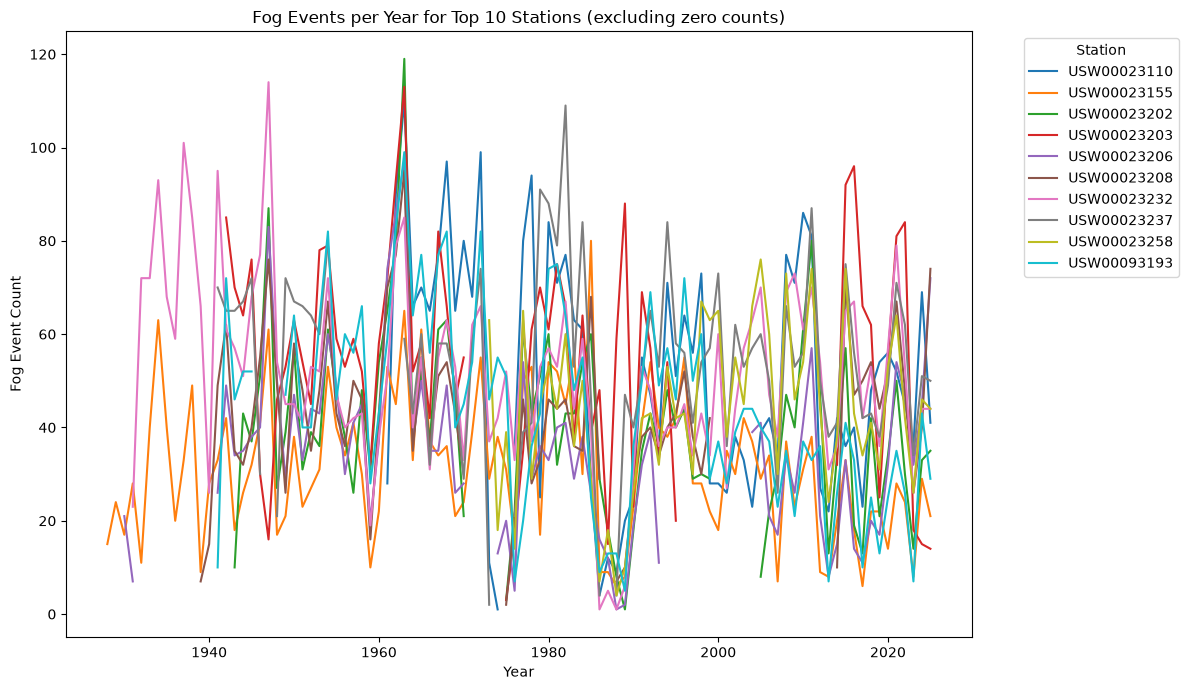

In [31]:
plot_df_nozeros = plot_df.replace(0, np.nan)

plot_df_nozeros.plot(figsize=(12, 7))
plt.title('Fog Events per Year for Top 10 Stations (excluding zero counts)')
plt.xlabel('Year')
plt.ylabel('Fog Event Count')
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()